# Customer Segmentation & Churn Pattern Analytics in European Banking

## Notebook 03: Exploratory Data Analysis

### Objective

This notebook explores the demographic, financial, behavioural, and geographic characteristics of European banking customers.

The analysis focuses on:

- Measuring the overall customer churn rate
- Understanding the customer population
- Comparing retained and churned customers
- Identifying high-risk demographic and financial groups
- Analysing churn across geography, age, balance, credit score, tenure, and product usage
- Producing business insights for customer-retention planning
- Generating charts and summary tables for the Streamlit dashboard and research paper

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Project utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
current_directory = Path.cwd()

if current_directory.name.lower() == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

data_directory = project_root / "data"
output_directory = project_root / "outputs"
chart_directory = output_directory / "charts"
table_directory = output_directory / "tables"

chart_directory.mkdir(parents=True, exist_ok=True)
table_directory.mkdir(parents=True, exist_ok=True)

analytics_dataset_path = (
    data_directory / "bank_customer_churn_analytics.csv"
)

print("Project root          :", project_root)
print("Analytics dataset path:", analytics_dataset_path)
print("Chart output directory:", chart_directory)
print("Table output directory:", table_directory)

Project root          : d:\Customer_Segmentation_Churn_Banking
Analytics dataset path: d:\Customer_Segmentation_Churn_Banking\data\bank_customer_churn_analytics.csv
Chart output directory: d:\Customer_Segmentation_Churn_Banking\outputs\charts
Table output directory: d:\Customer_Segmentation_Churn_Banking\outputs\tables


In [3]:
if not analytics_dataset_path.exists():
    raise FileNotFoundError(
        f"Analytics dataset not found at: {analytics_dataset_path}\n"
        "Complete Notebook 02 before running Notebook 03."
    )

df = pd.read_csv(analytics_dataset_path)

print("Analytics dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

Analytics dataset loaded successfully.
Rows    : 10,000
Columns : 15


In [4]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,Credit_Card_Status,IsActiveMember,Activity_Status,EstimatedSalary,Exited,Churn_Status
0,15634602,619,France,Female,42,2,0.00,1,1,Has Credit Card,1,Active,"101,348.88",1,Churned
1,15647311,608,Spain,Female,41,1,"83,807.86",1,0,No Credit Card,1,Active,"112,542.58",0,Retained
2,15619304,502,France,Female,42,8,"159,660.80",3,1,Has Credit Card,0,Inactive,"113,931.57",1,Churned
3,15701354,699,France,Female,39,1,0.00,2,0,No Credit Card,0,Inactive,"93,826.63",0,Retained
4,15737888,850,Spain,Female,43,2,"125,510.82",1,1,Has Credit Card,1,Active,"79,084.10",0,Retained


In [5]:
required_columns = [
    "CustomerId",
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "Credit_Card_Status",
    "IsActiveMember",
    "Activity_Status",
    "EstimatedSalary",
    "Exited",
    "Churn_Status"
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise KeyError(
        "The following required columns are missing: "
        f"{missing_required_columns}"
    )

print("Validation passed: All required columns are available.")

Validation passed: All required columns are available.


In [6]:
print("=" * 65)
print("DATASET VERIFICATION")
print("=" * 65)

print(f"Dataset shape          : {df.shape}")
print(f"Total missing values   : {df.isna().sum().sum():,}")
print(f"Duplicate rows         : {df.duplicated().sum():,}")
print(
    f"Duplicate Customer IDs : "
    f"{df['CustomerId'].duplicated().sum():,}"
)

print("\nData types:")
print(df.dtypes)

DATASET VERIFICATION
Dataset shape          : (10000, 15)
Total missing values   : 0
Duplicate rows         : 0
Duplicate Customer IDs : 0

Data types:
CustomerId              int64
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
Credit_Card_Status     object
IsActiveMember          int64
Activity_Status        object
EstimatedSalary       float64
Exited                  int64
Churn_Status           object
dtype: object


In [7]:
dataset_overview = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Variables",
        "Numerical Variables",
        "Categorical Variables",
        "Missing Values",
        "Duplicate Rows",
        "Countries",
        "Minimum Customer Age",
        "Maximum Customer Age"
    ],
    "Value": [
        len(df),
        df.shape[1],
        len(df.select_dtypes(include=np.number).columns),
        len(df.select_dtypes(exclude=np.number).columns),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        df["Geography"].nunique(),
        int(df["Age"].min()),
        int(df["Age"].max())
    ]
})

dataset_overview

,Metric,Value
0,Total Customers,10000
1,Total Variables,15
2,Numerical Variables,10
3,Categorical Variables,5
4,Missing Values,0
5,Duplicate Rows,0
6,Countries,3
7,Minimum Customer Age,18
8,Maximum Customer Age,92


In [8]:
dataset_overview.to_csv(
    table_directory / "eda_dataset_overview.csv",
    index=False
)

print("Dataset overview saved successfully.")

Dataset overview saved successfully.


In [9]:
numerical_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

numerical_summary = (
    df[numerical_columns]
    .describe()
    .T
    .rename(columns={
        "count": "Count",
        "mean": "Mean",
        "std": "Standard_Deviation",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum"
    })
)

numerical_summary

,Count,Mean,Standard_Deviation,Minimum,Q1,Median,Q3,Maximum
CreditScore,"10,000.00",650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,"10,000.00",38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,"10,000.00",5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,"10,000.00","76,485.89","62,397.41",0.00,0.00,"97,198.54","127,644.24","250,898.09"
NumOfProducts,"10,000.00",1.53,0.58,1.00,1.00,1.00,2.00,4.00
EstimatedSalary,"10,000.00","100,090.24","57,510.49",11.58,"51,002.11","100,193.91","149,388.25","199,992.48"


In [10]:
numerical_summary["Missing_Values"] = (
    df[numerical_columns].isna().sum()
)

numerical_summary["Unique_Values"] = (
    df[numerical_columns].nunique()
)

numerical_summary

,Count,Mean,Standard_Deviation,Minimum,Q1,Median,Q3,Maximum,Missing_Values,Unique_Values
CreditScore,"10,000.00",650.53,96.65,350.00,584.00,652.00,718.00,850.00,0,460
Age,"10,000.00",38.92,10.49,18.00,32.00,37.00,44.00,92.00,0,70
Tenure,"10,000.00",5.01,2.89,0.00,3.00,5.00,7.00,10.00,0,11
Balance,"10,000.00","76,485.89","62,397.41",0.00,0.00,"97,198.54","127,644.24","250,898.09",0,6382
NumOfProducts,"10,000.00",1.53,0.58,1.00,1.00,1.00,2.00,4.00,0,4
EstimatedSalary,"10,000.00","100,090.24","57,510.49",11.58,"51,002.11","100,193.91","149,388.25","199,992.48",0,9999


In [11]:
numerical_summary.to_csv(
    table_directory / "eda_numerical_summary.csv"
)

print("Numerical summary saved successfully.")

Numerical summary saved successfully.


In [12]:
categorical_columns = [
    "Geography",
    "Gender",
    "Credit_Card_Status",
    "Activity_Status",
    "Churn_Status"
]

categorical_summary_records = []

for column in categorical_columns:
    categorical_summary_records.append({
        "Column": column,
        "Unique_Values": df[column].nunique(),
        "Most_Common_Value": df[column].mode().iloc[0],
        "Most_Common_Count": int(
            df[column].value_counts().iloc[0]
        ),
        "Missing_Values": int(df[column].isna().sum())
    })

categorical_summary = pd.DataFrame(
    categorical_summary_records
)

categorical_summary

,Column,Unique_Values,Most_Common_Value,Most_Common_Count,Missing_Values
0,Geography,3,France,5014,0
1,Gender,2,Male,5457,0
2,Credit_Card_Status,2,Has Credit Card,7055,0
3,Activity_Status,2,Active,5151,0
4,Churn_Status,2,Retained,7963,0


In [13]:
categorical_summary.to_csv(
    table_directory / "eda_categorical_summary.csv",
    index=False
)

print("Categorical summary saved successfully.")

Categorical summary saved successfully.


In [14]:
total_customers = len(df)

retained_customers = int(
    (df["Exited"] == 0).sum()
)

churned_customers = int(
    (df["Exited"] == 1).sum()
)

overall_churn_rate = (
    churned_customers / total_customers * 100
)

retention_rate = (
    retained_customers / total_customers * 100
)

active_customers = int(
    (df["IsActiveMember"] == 1).sum()
)

inactive_customers = int(
    (df["IsActiveMember"] == 0).sum()
)

active_customer_rate = (
    active_customers / total_customers * 100
)

inactive_customer_rate = (
    inactive_customers / total_customers * 100
)

average_balance = df["Balance"].mean()
median_balance = df["Balance"].median()
average_credit_score = df["CreditScore"].mean()
average_customer_age = df["Age"].mean()
average_products = df["NumOfProducts"].mean()

In [15]:
print("=" * 60)
print("CORE BANKING CUSTOMER KPIs")
print("=" * 60)

print(f"Total customers       : {total_customers:,}")
print(f"Retained customers    : {retained_customers:,}")
print(f"Churned customers     : {churned_customers:,}")
print(f"Overall churn rate    : {overall_churn_rate:.2f}%")
print(f"Customer retention rate: {retention_rate:.2f}%")

print(f"\nActive customers      : {active_customers:,}")
print(f"Inactive customers    : {inactive_customers:,}")
print(f"Active customer rate  : {active_customer_rate:.2f}%")
print(f"Inactive customer rate: {inactive_customer_rate:.2f}%")

print(f"\nAverage balance       : {average_balance:,.2f}")
print(f"Median balance        : {median_balance:,.2f}")
print(f"Average credit score  : {average_credit_score:.2f}")
print(f"Average customer age  : {average_customer_age:.2f}")
print(f"Average products      : {average_products:.2f}")

CORE BANKING CUSTOMER KPIs
Total customers       : 10,000
Retained customers    : 7,963
Churned customers     : 2,037
Overall churn rate    : 20.37%
Customer retention rate: 79.63%

Active customers      : 5,151
Inactive customers    : 4,849
Active customer rate  : 51.51%
Inactive customer rate: 48.49%

Average balance       : 76,485.89
Median balance        : 97,198.54
Average credit score  : 650.53
Average customer age  : 38.92
Average products      : 1.53


In [16]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Retained Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "Retention Rate",
        "Active Customers",
        "Inactive Customers",
        "Active Customer Rate",
        "Average Balance",
        "Median Balance",
        "Average Credit Score",
        "Average Customer Age",
        "Average Number of Products"
    ],
    "Value": [
        total_customers,
        retained_customers,
        churned_customers,
        round(overall_churn_rate, 2),
        round(retention_rate, 2),
        active_customers,
        inactive_customers,
        round(active_customer_rate, 2),
        round(average_balance, 2),
        round(median_balance, 2),
        round(average_credit_score, 2),
        round(average_customer_age, 2),
        round(average_products, 2)
    ],
    "Unit": [
        "Customers",
        "Customers",
        "Customers",
        "Percent",
        "Percent",
        "Customers",
        "Customers",
        "Percent",
        "Currency",
        "Currency",
        "Score",
        "Years",
        "Products"
    ]
})

kpi_summary

,KPI,Value,Unit
0,Total Customers,"10,000.00",Customers
1,Retained Customers,"7,963.00",Customers
2,Churned Customers,"2,037.00",Customers
3,Overall Churn Rate,20.37,Percent
4,Retention Rate,79.63,Percent
5,Active Customers,"5,151.00",Customers
6,Inactive Customers,"4,849.00",Customers
7,Active Customer Rate,51.51,Percent
8,Average Balance,"76,485.89",Currency
9,Median Balance,"97,198.54",Currency


In [17]:
kpi_summary.to_csv(
    table_directory / "core_banking_kpi_summary.csv",
    index=False
)

print("Core KPI summary saved successfully.")

Core KPI summary saved successfully.


In [18]:
churn_distribution = (
    df.groupby(["Exited", "Churn_Status"])
    .agg(
        Customer_Count=("CustomerId", "count")
    )
    .reset_index()
)

churn_distribution["Percentage"] = (
    churn_distribution["Customer_Count"]
    / churn_distribution["Customer_Count"].sum()
    * 100
).round(2)

churn_distribution

,Exited,Churn_Status,Customer_Count,Percentage
0,0,Retained,7963,79.63
1,1,Churned,2037,20.37


In [19]:
churn_distribution.to_csv(
    table_directory / "churn_distribution_summary.csv",
    index=False
)

print("Churn distribution summary saved successfully.")

Churn distribution summary saved successfully.


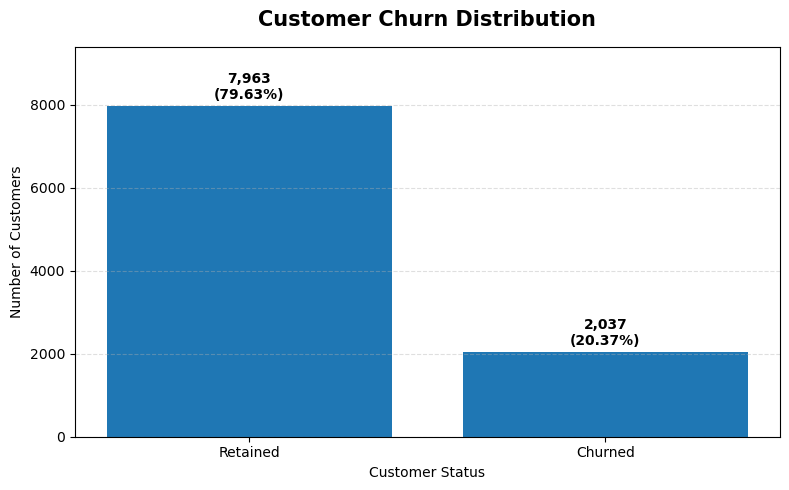

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\01_customer_churn_distribution.png


In [20]:
churn_plot_data = (
    df["Churn_Status"]
    .value_counts()
    .reindex(["Retained", "Churned"])
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    churn_plot_data.index,
    churn_plot_data.values
)

ax.set_title(
    "Customer Churn Distribution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Customer Status")
ax.set_ylabel("Number of Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, count in zip(bars, churn_plot_data.values):
    percentage = count / total_customers * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    churn_plot_data.max() * 1.18
)

plt.tight_layout()

chart_path = (
    chart_directory / "01_customer_churn_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

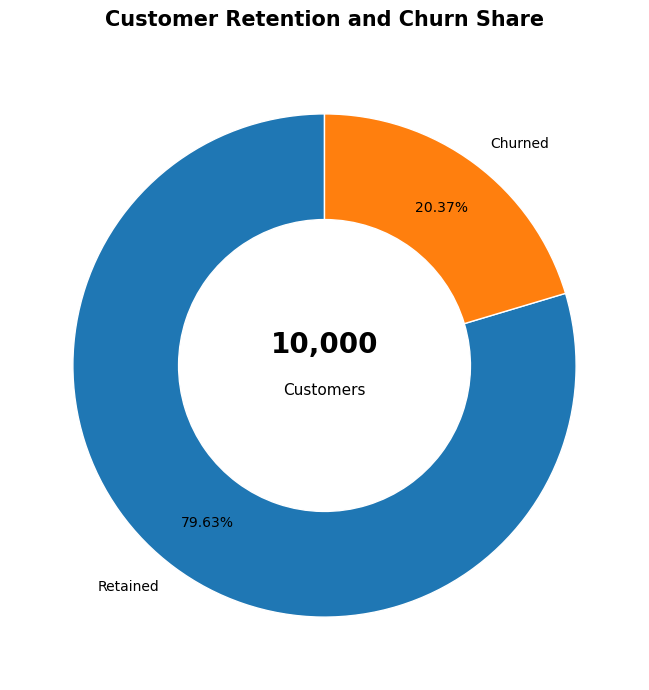

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\02_customer_churn_donut.png


In [21]:
churn_donut_data = (
    df["Churn_Status"]
    .value_counts()
    .reindex(["Retained", "Churned"])
)

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    churn_donut_data.values,
    labels=churn_donut_data.index,
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white"
    }
)

ax.text(
    0,
    0.08,
    f"{total_customers:,}",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    0,
    -0.10,
    "Customers",
    ha="center",
    va="center",
    fontsize=11
)

ax.set_title(
    "Customer Retention and Churn Share",
    fontsize=15,
    fontweight="bold",
    pad=18
)

plt.tight_layout()

chart_path = (
    chart_directory / "02_customer_churn_donut.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

## Churn Distribution Findings

- The dataset contains **10,000 banking customers**.
- A total of **7,963 customers were retained**, representing **79.63%** of the customer base.
- A total of **2,037 customers exited the bank**, producing an overall churn rate of **20.37%**.
- Approximately one out of every five customers in the dataset has churned.
- The target variable is moderately imbalanced because retained customers significantly outnumber churned customers.
- The churn level is large enough to justify detailed demographic, geographic, financial, and behavioural investigation.
- Machine-learning model evaluation should not rely only on accuracy because a model could favour the larger retained class.

In [22]:
churn_numeric_comparison = (
    df.groupby("Churn_Status")[numerical_columns]
    .mean()
    .T
)

churn_numeric_comparison["Difference"] = (
    churn_numeric_comparison["Churned"]
    - churn_numeric_comparison["Retained"]
)

churn_numeric_comparison["Percentage_Difference"] = (
    churn_numeric_comparison["Difference"]
    / churn_numeric_comparison["Retained"]
    * 100
).round(2)

churn_numeric_comparison

Churn_Status,Churned,Retained,Difference,Percentage_Difference
CreditScore,645.35,651.85,-6.50,-1.00
Age,44.84,37.41,7.43,19.86
Tenure,4.93,5.03,-0.10,-2.00
Balance,"91,108.54","72,745.30","18,363.24",25.24
NumOfProducts,1.48,1.54,-0.07,-4.47
EstimatedSalary,"101,465.68","99,738.39","1,727.29",1.73


In [23]:
churn_numeric_comparison.to_csv(
    table_directory /
    "retained_vs_churned_numeric_comparison.csv"
)

print(
    "Retained-versus-churned numerical comparison saved."
)

Retained-versus-churned numerical comparison saved.


In [24]:
formatted_churn_comparison = (
    df.groupby("Churn_Status")
    .agg(
        Customers=("CustomerId", "count"),
        Average_Age=("Age", "mean"),
        Average_Credit_Score=("CreditScore", "mean"),
        Average_Tenure=("Tenure", "mean"),
        Average_Balance=("Balance", "mean"),
        Average_Products=("NumOfProducts", "mean"),
        Average_Salary=("EstimatedSalary", "mean"),
        Active_Customer_Rate=("IsActiveMember", "mean"),
        Credit_Card_Ownership_Rate=("HasCrCard", "mean")
    )
    .reset_index()
)

formatted_churn_comparison[
    "Active_Customer_Rate"
] = (
    formatted_churn_comparison[
        "Active_Customer_Rate"
    ] * 100
).round(2)

formatted_churn_comparison[
    "Credit_Card_Ownership_Rate"
] = (
    formatted_churn_comparison[
        "Credit_Card_Ownership_Rate"
    ] * 100
).round(2)

numeric_columns_to_round = [
    "Average_Age",
    "Average_Credit_Score",
    "Average_Tenure",
    "Average_Balance",
    "Average_Products",
    "Average_Salary"
]

formatted_churn_comparison[
    numeric_columns_to_round
] = formatted_churn_comparison[
    numeric_columns_to_round
].round(2)

formatted_churn_comparison

,Churn_Status,Customers,Average_Age,Average_Credit_Score,Average_Tenure,Average_Balance,Average_Products,Average_Salary,Active_Customer_Rate,Credit_Card_Ownership_Rate
0,Churned,2037,44.84,645.35,4.93,"91,108.54",1.48,"101,465.68",36.08,69.91
1,Retained,7963,37.41,651.85,5.03,"72,745.30",1.54,"99,738.39",55.46,70.71


In [25]:
formatted_churn_comparison.to_csv(
    table_directory /
    "retained_vs_churned_customer_profile.csv",
    index=False
)

print(
    "Retained-versus-churned customer profile saved."
)

Retained-versus-churned customer profile saved.


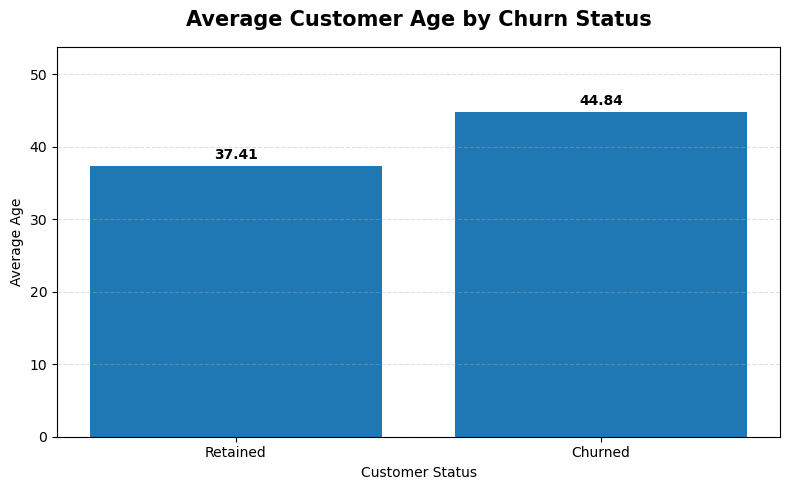

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\03_average_age_by_churn_status.png


In [26]:
age_by_churn = (
    df.groupby("Churn_Status")["Age"]
    .mean()
    .reindex(["Retained", "Churned"])
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    age_by_churn.index,
    age_by_churn.values
)

ax.set_title(
    "Average Customer Age by Churn Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Customer Status")
ax.set_ylabel("Average Age")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(bars, age_by_churn.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    age_by_churn.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "03_average_age_by_churn_status.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

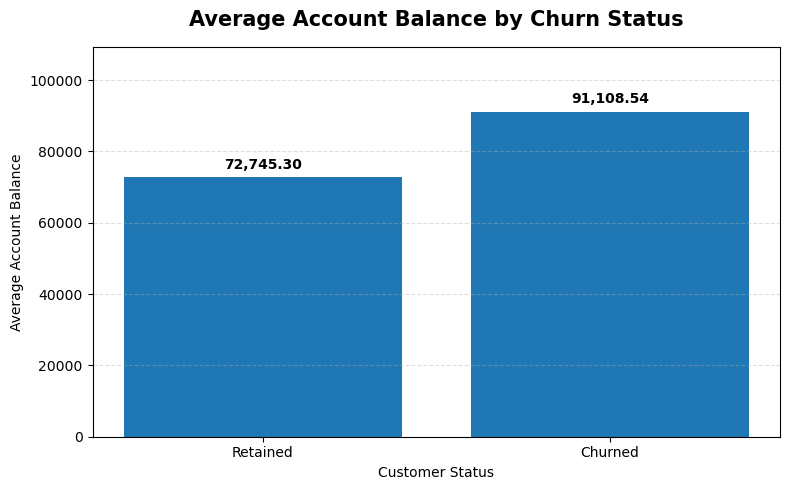

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\04_average_balance_by_churn_status.png


In [27]:
balance_by_churn = (
    df.groupby("Churn_Status")["Balance"]
    .mean()
    .reindex(["Retained", "Churned"])
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    balance_by_churn.index,
    balance_by_churn.values
)

ax.set_title(
    "Average Account Balance by Churn Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Customer Status")
ax.set_ylabel("Average Account Balance")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(bars, balance_by_churn.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f"{value:,.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    balance_by_churn.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "04_average_balance_by_churn_status.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

## Initial Retained vs Churned Customer Findings

- The average age of retained customers is approximately **37.41 years**, while the average age of churned customers is approximately **44.84 years**.
- Churned customers are, on average, about **7.43 years older** than retained customers.
- The average account balance of churned customers is **91,108.54**, compared with **72,745.30** among retained customers.
- The average credit score of retained customers is **651.85**, while churned customers have an average credit score of **645.35**.
- The average number of products held by retained customers is **1.54**, compared with **1.48** among churned customers.
- Average tenure is broadly similar between the two groups: **5.03 years** for retained customers and **4.93 years** for churned customers.
- Churned customers have a slightly higher average estimated salary of **101,465.68**, compared with **99,738.39** among retained customers.
- Only **36.08%** of churned customers are active members, compared with **55.46%** of retained customers, indicating that customer engagement is strongly associated with retention.
- Credit card ownership is almost identical between retained (**70.71%**) and churned (**69.91%**) customers, suggesting that credit card ownership alone is unlikely to be a strong predictor of churn.
- Initial evidence suggests that age, account balance, and customer activity show stronger relationships with churn than credit score, tenure, salary, or credit card ownership.
- These observations represent group-level averages and should be validated through more detailed segmented analysis before drawing final business conclusions.

## 3.21 Credit Score Distribution

Credit score is an important indicator of customer creditworthiness. This section analyses the overall distribution of customer credit scores and identifies potential outliers, central tendencies, and variability within the customer base.

In [28]:
credit_score_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation",
        "Q1",
        "Q3"
    ],
    "Value": [
        df["CreditScore"].min(),
        df["CreditScore"].max(),
        round(df["CreditScore"].mean(),2),
        round(df["CreditScore"].median(),2),
        round(df["CreditScore"].std(),2),
        df["CreditScore"].quantile(0.25),
        df["CreditScore"].quantile(0.75)
    ]
})

credit_score_summary

,Statistic,Value
0,Minimum,350.00
1,Maximum,850.00
2,Mean,650.53
3,Median,652.00
4,Standard Deviation,96.65
5,Q1,584.00
6,Q3,718.00


In [29]:
credit_score_summary.to_csv(
    table_directory / "credit_score_summary.csv",
    index=False
)

print("Credit score summary saved.")

Credit score summary saved.


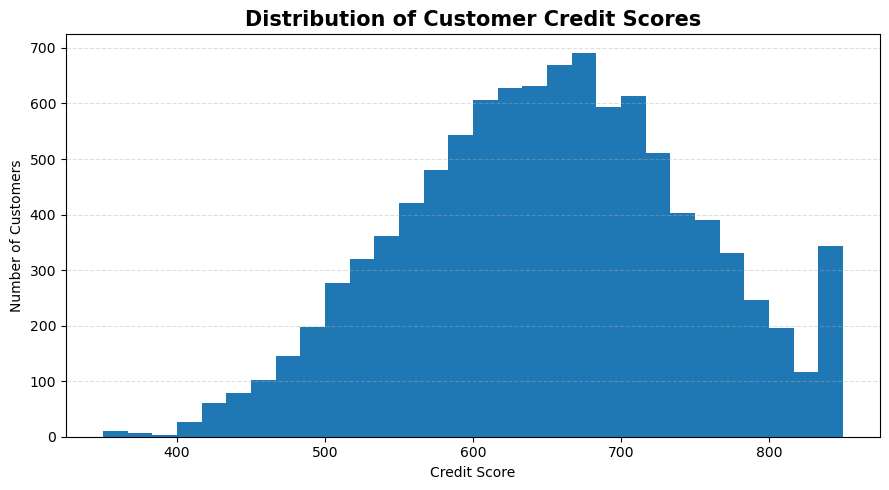

d:\Customer_Segmentation_Churn_Banking\outputs\charts\05_credit_score_distribution.png


In [30]:
fig, ax = plt.subplots(figsize=(9,5))

ax.hist(
    df["CreditScore"],
    bins=30
)

ax.set_title(
    "Distribution of Customer Credit Scores",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Credit Score")
ax.set_ylabel("Number of Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "05_credit_score_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(chart_path)

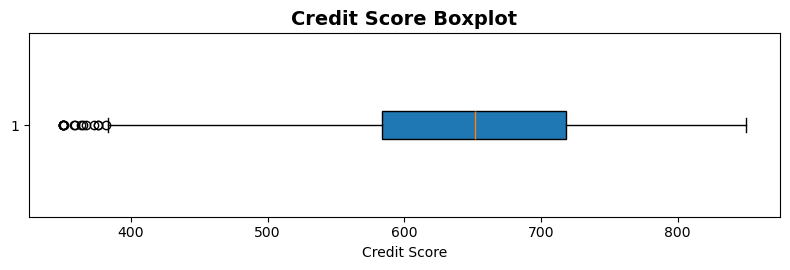

d:\Customer_Segmentation_Churn_Banking\outputs\charts\06_credit_score_boxplot.png


In [31]:
fig, ax = plt.subplots(figsize=(8,2.8))

ax.boxplot(
    df["CreditScore"],
    vert=False,
    patch_artist=True
)

ax.set_title(
    "Credit Score Boxplot",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Credit Score")

plt.tight_layout()

chart_path = (
    chart_directory /
    "06_credit_score_boxplot.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(chart_path)

In [32]:
credit_bins = [
    300,
    580,
    670,
    740,
    850
]

credit_labels = [
    "Poor",
    "Fair",
    "Good",
    "Excellent"
]

df["CreditScoreBand"] = pd.cut(
    df["CreditScore"],
    bins=credit_bins,
    labels=credit_labels,
    include_lowest=True
)

credit_band_summary = (
    df["CreditScoreBand"]
    .value_counts()
    .sort_index()
    .reset_index()
)

credit_band_summary.columns = [
    "Credit_Score_Band",
    "Customers"
]

credit_band_summary["Percentage"] = (
    credit_band_summary["Customers"]
    / len(df)
    *100
).round(2)

credit_band_summary

,Credit_Score_Band,Customers,Percentage
0,Poor,2393,23.93
1,Fair,3350,33.50
2,Good,2397,23.97
3,Excellent,1860,18.60


In [33]:
credit_band_summary.to_csv(
    table_directory /
    "credit_score_band_summary.csv",
    index=False
)

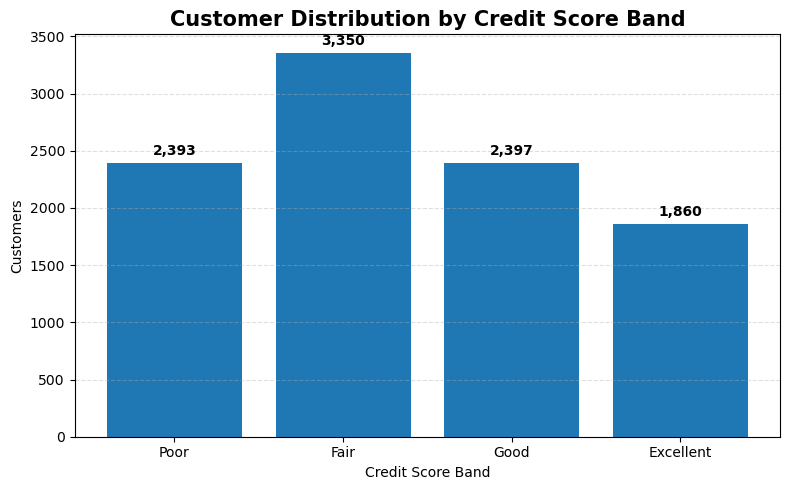

d:\Customer_Segmentation_Churn_Banking\outputs\charts\07_credit_score_band_distribution.png


In [34]:
credit_band_plot = (
    credit_band_summary
    .set_index("Credit_Score_Band")
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    credit_band_plot.index,
    credit_band_plot["Customers"]
)

ax.set_title(
    "Customer Distribution by Credit Score Band",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Credit Score Band")
ax.set_ylabel("Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    credit_band_plot["Customers"]
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+70,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "07_credit_score_band_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(chart_path)

In [35]:
credit_churn_summary = (
    df.groupby(
        ["CreditScoreBand","Churn_Status"],
        observed=False
    )
    .size()
    .reset_index(name="Customers")
)

credit_churn_summary["Percentage"] = (
    credit_churn_summary
    .groupby("CreditScoreBand")["Customers"]
    .transform(lambda x: x/x.sum()*100)
).round(2)

credit_churn_summary

,CreditScoreBand,Churn_Status,Customers,Percentage
0,Poor,Churned,530,22.15
1,Poor,Retained,1863,77.85
2,Fair,Churned,683,20.39
3,Fair,Retained,2667,79.61
4,Good,Churned,451,18.82
5,Good,Retained,1946,81.18
6,Excellent,Churned,373,20.05
7,Excellent,Retained,1487,79.95


In [36]:
credit_churn_summary.to_csv(
    table_directory /
    "credit_score_churn_summary.csv",
    index=False
)

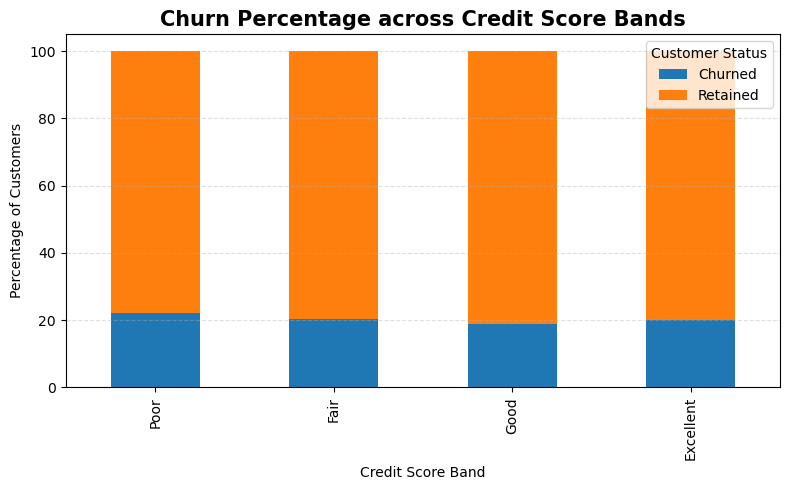

In [38]:
credit_pivot = (
    credit_churn_summary
    .pivot(
        index="CreditScoreBand",
        columns="Churn_Status",
        values="Percentage"
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

credit_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Churn Percentage across Credit Score Bands",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Credit Score Band")
ax.set_ylabel("Percentage of Customers")

ax.legend(title="Customer Status")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "08_credit_score_band_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Credit Score Analysis Findings

- Customer credit scores range from **350** to **850**, with an average score of **650.53**.
- The largest customer segment falls within the **Fair** credit score band, representing **33.50%** of all customers.
- The **Good** credit score band exhibits the lowest churn rate (**18.82%**), while the **Poor** credit score band records the highest churn rate (**22.15%**).
- Despite this variation, churn percentages across all credit score bands remain relatively close, ranging only from **18.82%** to **22.15%**.
- The average credit score difference between retained and churned customers is only about **6.5 points**, indicating that credit score alone is not a strong predictor of customer churn.
- Credit score should therefore be analysed together with customer activity, account balance, age, geography, and product usage to better understand churn behaviour.

## 3.30 Customer Age Distribution

Customer age is an important demographic factor influencing banking behaviour, financial needs, and customer retention. This section analyses the overall age distribution, customer age groups, and churn behaviour across different age categories.

In [39]:
age_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation",
        "Q1",
        "Q3"
    ],
    "Value": [
        df["Age"].min(),
        df["Age"].max(),
        round(df["Age"].mean(), 2),
        round(df["Age"].median(), 2),
        round(df["Age"].std(), 2),
        df["Age"].quantile(0.25),
        df["Age"].quantile(0.75)
    ]
})

age_summary

,Statistic,Value
0,Minimum,18.00
1,Maximum,92.00
2,Mean,38.92
3,Median,37.00
4,Standard Deviation,10.49
5,Q1,32.00
6,Q3,44.00


In [40]:
age_summary.to_csv(
    table_directory / "age_summary.csv",
    index=False
)

print("Age summary saved.")

Age summary saved.


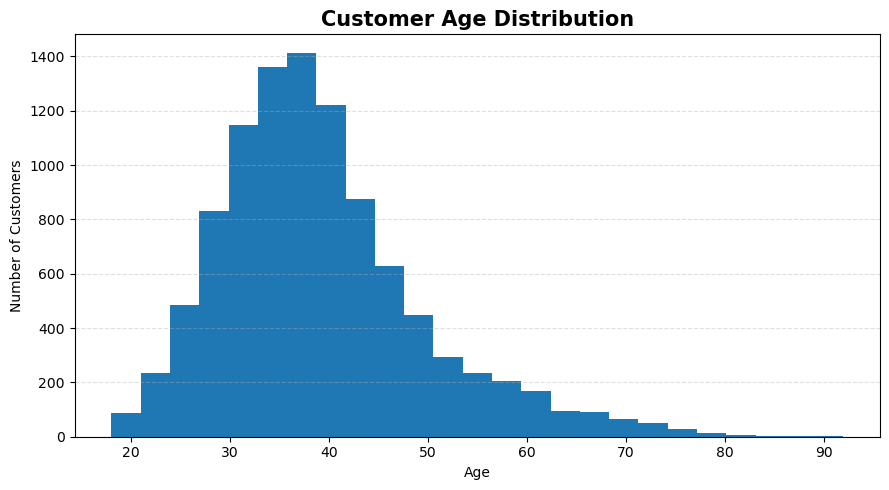

In [41]:
fig, ax = plt.subplots(figsize=(9,5))

ax.hist(
    df["Age"],
    bins=25
)

ax.set_title(
    "Customer Age Distribution",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "09_age_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

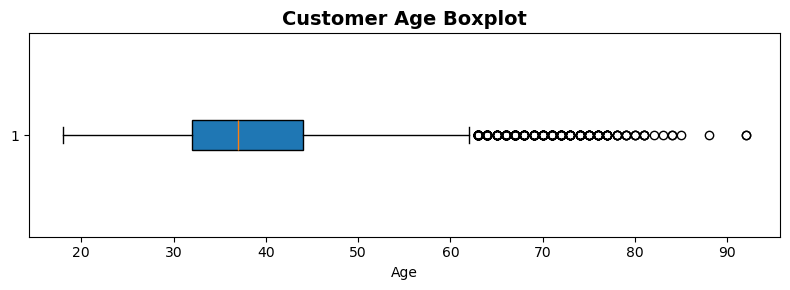

In [42]:
fig, ax = plt.subplots(figsize=(8,3))

ax.boxplot(
    df["Age"],
    vert=False,
    patch_artist=True
)

ax.set_title(
    "Customer Age Boxplot",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Age")

plt.tight_layout()

chart_path = (
    chart_directory /
    "10_age_boxplot.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
age_bins = [
    18,
    30,
    40,
    50,
    60,
    100
]

age_labels = [
    "18-30",
    "31-40",
    "41-50",
    "51-60",
    "60+"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [44]:
age_group_summary = (
    df["AgeGroup"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_summary.columns = [
    "Age_Group",
    "Customers"
]

age_group_summary["Percentage"] = (
    age_group_summary["Customers"]
    / len(df)
    *100
).round(2)

age_group_summary

,Age_Group,Customers,Percentage
0,18-30,1968,19.68
1,31-40,4451,44.51
2,41-50,2320,23.20
3,51-60,797,7.97
4,60+,464,4.64


In [45]:
age_group_summary.to_csv(
    table_directory /
    "age_group_summary.csv",
    index=False
)

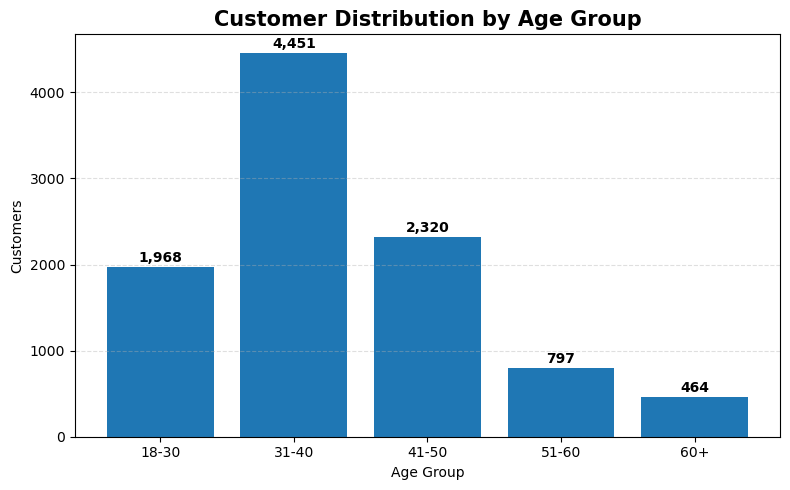

In [46]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    age_group_summary["Age_Group"],
    age_group_summary["Customers"]
)

ax.set_title(
    "Customer Distribution by Age Group",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    age_group_summary["Customers"]
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+60,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "11_age_group_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
age_churn_summary = (
    df.groupby(
        ["AgeGroup", "Churn_Status"],
        observed=False
    )
    .size()
    .reset_index(name="Customers")
)

age_churn_summary["Percentage"] = (
    age_churn_summary
    .groupby("AgeGroup")["Customers"]
    .transform(lambda x: x/x.sum()*100)
).round(2)

age_churn_summary

,AgeGroup,Churn_Status,Customers,Percentage
0,18-30,Churned,148,7.52
1,18-30,Retained,1820,92.48
2,31-40,Churned,538,12.09
3,31-40,Retained,3913,87.91
4,41-50,Churned,788,33.97
5,41-50,Retained,1532,66.03
6,51-60,Churned,448,56.21
7,51-60,Retained,349,43.79
8,60+,Churned,115,24.78
9,60+,Retained,349,75.22


In [48]:
age_churn_summary.to_csv(
    table_directory /
    "age_group_churn_summary.csv",
    index=False
)

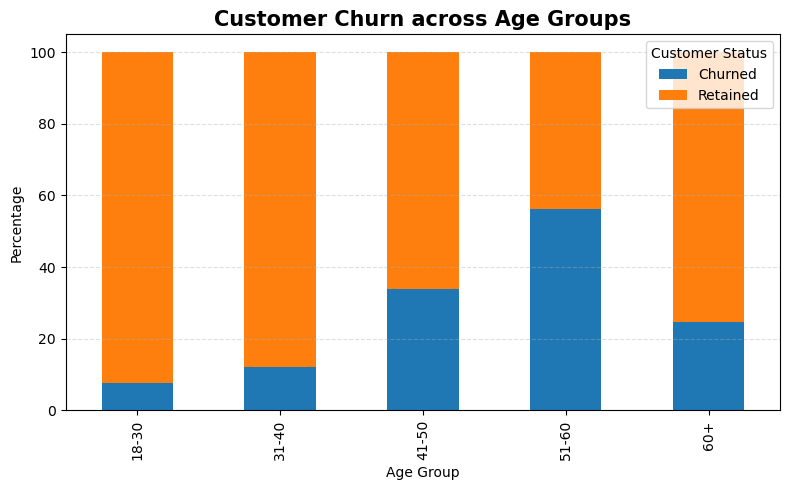

In [49]:
age_pivot = (
    age_churn_summary
    .pivot(
        index="AgeGroup",
        columns="Churn_Status",
        values="Percentage"
    )
)

fig, ax = plt.subplots(figsize=(8,5))

age_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Customer Churn across Age Groups",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Percentage")

ax.legend(title="Customer Status")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "12_age_group_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

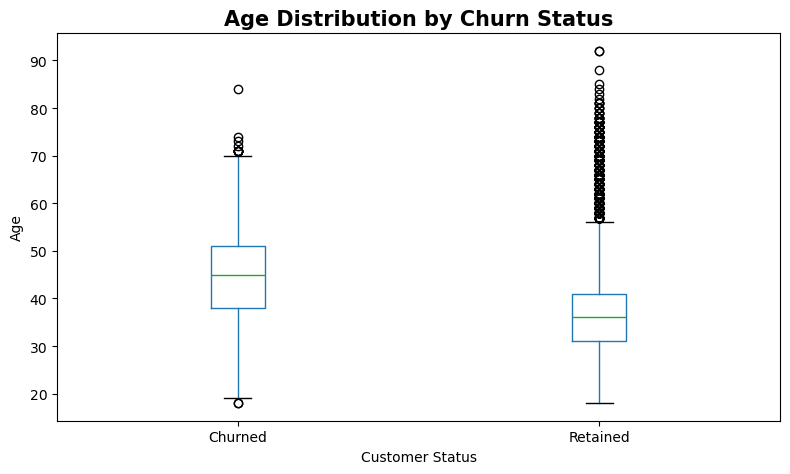

In [50]:
fig, ax = plt.subplots(figsize=(8,5))

df.boxplot(
    column="Age",
    by="Churn_Status",
    ax=ax,
    grid=False
)

plt.suptitle("")

ax.set_title(
    "Age Distribution by Churn Status",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Customer Status")
ax.set_ylabel("Age")

plt.tight_layout()

chart_path = (
    chart_directory /
    "13_age_by_churn_boxplot.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Age Analysis Findings

- Customer ages range from **18** to **92** years, with an average age of **38.92 years**.
- The largest proportion of customers belongs to the **31–40** age group, representing **44.51%** of the customer base.
- Customer churn increases substantially with age up to the **51–60** age group.
- Customers aged **51–60** exhibit the highest churn rate at **56.21%**, indicating that more than half of the customers in this age category leave the bank.
- Younger customers demonstrate considerably higher retention, with the **18–30** age group showing a churn rate of only **7.52%**.
- The **41–50** age group also experiences elevated churn (**33.97%**), suggesting that churn risk begins increasing after approximately 40 years of age.
- Customers aged **60+** show a lower churn rate (**24.78%**) than the **51–60** group, indicating that churn does not continue increasing indefinitely with age.
- The age distribution and churn comparison confirm that customer age is one of the strongest demographic predictors of churn in this dataset and should be considered a key feature for predictive modelling and customer-retention strategies.

## 3.41 Customer Distribution by Geography

Customer geography plays an important role in banking analytics because customer behaviour, financial products, and retention strategies often vary across regions.

This section analyses:

- Customer distribution across European countries
- Churn rate by geography
- Regional customer characteristics
- Geographic business insights

In [51]:
geography_summary = (
    df["Geography"]
    .value_counts()
    .sort_index()
    .reset_index()
)

geography_summary.columns = [
    "Country",
    "Customers"
]

geography_summary["Percentage"] = (
    geography_summary["Customers"]
    / len(df)
    *100
).round(2)

geography_summary

,Country,Customers,Percentage
0,France,5014,50.14
1,Germany,2509,25.09
2,Spain,2477,24.77


In [52]:
geography_summary.to_csv(
    table_directory /
    "geography_summary.csv",
    index=False
)

print("Geography summary saved.")

Geography summary saved.


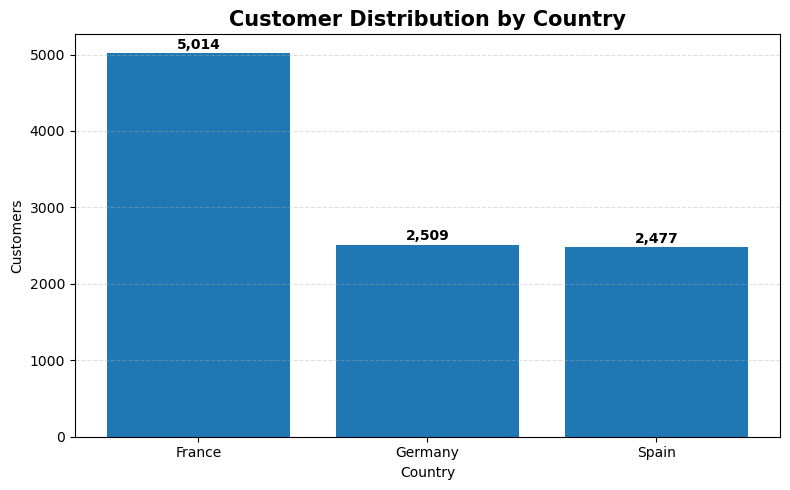

In [53]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    geography_summary["Country"],
    geography_summary["Customers"]
)

ax.set_title(
    "Customer Distribution by Country",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Country")
ax.set_ylabel("Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    geography_summary["Customers"]
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+60,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "14_customer_distribution_by_country.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
geography_churn_summary = (
    df.groupby(
        ["Geography","Churn_Status"],
        observed=False
    )
    .size()
    .reset_index(name="Customers")
)

geography_churn_summary["Percentage"] = (
    geography_churn_summary
    .groupby("Geography")["Customers"]
    .transform(lambda x: x/x.sum()*100)
).round(2)

geography_churn_summary

,Geography,Churn_Status,Customers,Percentage
0,France,Churned,810,16.15
1,France,Retained,4204,83.85
2,Germany,Churned,814,32.44
3,Germany,Retained,1695,67.56
4,Spain,Churned,413,16.67
5,Spain,Retained,2064,83.33


In [55]:
geography_churn_summary.to_csv(
    table_directory /
    "geography_churn_summary.csv",
    index=False
)

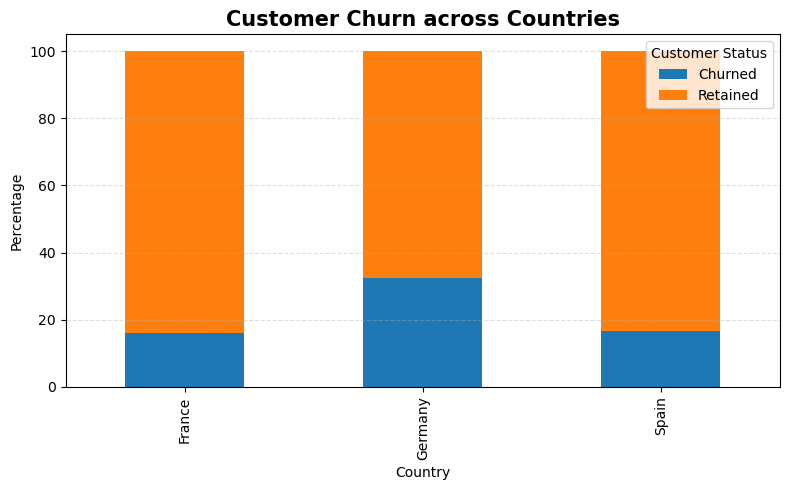

In [56]:
geo_pivot = (
    geography_churn_summary
    .pivot(
        index="Geography",
        columns="Churn_Status",
        values="Percentage"
    )
)

fig, ax = plt.subplots(figsize=(8,5))

geo_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Customer Churn across Countries",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Country")
ax.set_ylabel("Percentage")

ax.legend(title="Customer Status")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "15_country_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
country_kpis = (
    df.groupby("Geography")
    .agg(
        Customers=("CustomerId","count"),
        Average_Age=("Age","mean"),
        Average_CreditScore=("CreditScore","mean"),
        Average_Balance=("Balance","mean"),
        Average_Tenure=("Tenure","mean"),
        Average_Salary=("EstimatedSalary","mean"),
        Active_Rate=("IsActiveMember","mean"),
        Churn_Rate=("Exited","mean")
    )
    .reset_index()
)

country_kpis["Active_Rate"] = (
    country_kpis["Active_Rate"]*100
).round(2)

country_kpis["Churn_Rate"] = (
    country_kpis["Churn_Rate"]*100
).round(2)

country_kpis = country_kpis.round(2)

country_kpis

,Geography,Customers,Average_Age,Average_CreditScore,Average_Balance,Average_Tenure,Average_Salary,Active_Rate,Churn_Rate
0,France,5014,38.51,649.67,"62,092.64",5.00,"99,899.18",51.68,16.15
1,Germany,2509,39.77,651.45,"119,730.12",5.01,"101,113.44",49.74,32.44
2,Spain,2477,38.89,651.33,"61,818.15",5.03,"99,440.57",52.97,16.67


In [58]:
country_kpis.to_csv(
    table_directory /
    "country_kpis.csv",
    index=False
)

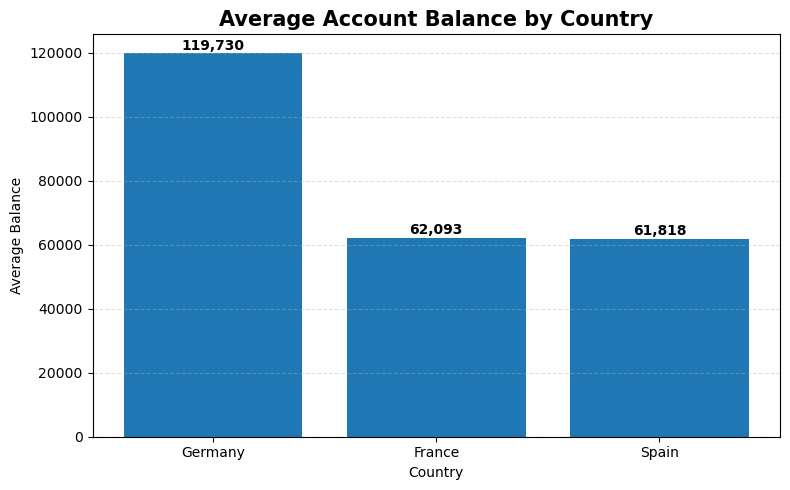

In [59]:
balance_country = (
    df.groupby("Geography")["Balance"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    balance_country.index,
    balance_country.values
)

ax.set_title(
    "Average Account Balance by Country",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Country")
ax.set_ylabel("Average Balance")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    balance_country.values
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+1200,
        f"{value:,.0f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "16_average_balance_by_country.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
geographic_risk_index = (
    country_kpis[
        ["Geography","Customers","Churn_Rate"]
    ]
    .sort_values(
        by="Churn_Rate",
        ascending=False
    )
)

geographic_risk_index["Risk_Level"] = np.select(
    [
        geographic_risk_index["Churn_Rate"] >= 30,
        geographic_risk_index["Churn_Rate"] >= 20
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

geographic_risk_index

,Geography,Customers,Churn_Rate,Risk_Level
1,Germany,2509,32.44,High
2,Spain,2477,16.67,Low
0,France,5014,16.15,Low


In [61]:
geographic_risk_index.to_csv(
    table_directory /
    "geographic_risk_index.csv",
    index=False
)

## Geography Analysis Findings

- France is the largest customer market, accounting for **50.14%** of all customers.
- Germany and Spain together represent **49.86%** of the customer base.
- **Germany** records the highest customer churn rate (**32.44%**), which is approximately double the churn rate observed in France (**16.15%**) and Spain (**16.67%**).
- **France** records the lowest churn rate among the three countries.
- Germany also has the highest average account balance (**119,730.12**), indicating that customers with larger balances in this region are more likely to leave the bank.
- Customer activity rates are relatively similar across the three countries, suggesting that geography has a stronger relationship with churn than customer activity alone.
- Based on the Geographic Risk Index, **Germany** is classified as a **High-Risk** region, while **France** and **Spain** are classified as **Low-Risk** regions.
- Geographic location is therefore one of the strongest business factors influencing customer churn and should be incorporated into retention strategies and predictive modelling.

## 3.50 Customer Gender Analysis

Customer gender is an important demographic characteristic that may influence banking behaviour, product adoption, and customer retention.

This section analyses:

- Gender distribution
- Customer churn by gender
- Average financial characteristics by gender
- Business insights based on gender differences

In [62]:
gender_summary = (
    df["Gender"]
    .value_counts()
    .sort_index()
    .reset_index()
)

gender_summary.columns = [
    "Gender",
    "Customers"
]

gender_summary["Percentage"] = (
    gender_summary["Customers"]
    / len(df)
    * 100
).round(2)

gender_summary

,Gender,Customers,Percentage
0,Female,4543,45.43
1,Male,5457,54.57


In [63]:
gender_summary.to_csv(
    table_directory /
    "gender_summary.csv",
    index=False
)

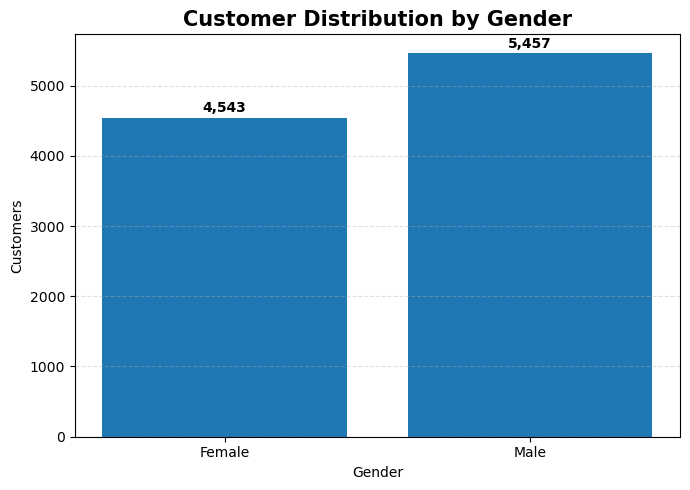

In [64]:
fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    gender_summary["Gender"],
    gender_summary["Customers"]
)

ax.set_title(
    "Customer Distribution by Gender",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Gender")
ax.set_ylabel("Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    gender_summary["Customers"]
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+80,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "17_gender_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
gender_churn_summary = (
    df.groupby(
        ["Gender","Churn_Status"],
        observed=False
    )
    .size()
    .reset_index(name="Customers")
)

gender_churn_summary["Percentage"] = (
    gender_churn_summary
    .groupby("Gender")["Customers"]
    .transform(lambda x: x/x.sum()*100)
).round(2)

gender_churn_summary

,Gender,Churn_Status,Customers,Percentage
0,Female,Churned,1139,25.07
1,Female,Retained,3404,74.93
2,Male,Churned,898,16.46
3,Male,Retained,4559,83.54


In [66]:
gender_churn_summary.to_csv(
    table_directory /
    "gender_churn_summary.csv",
    index=False
)

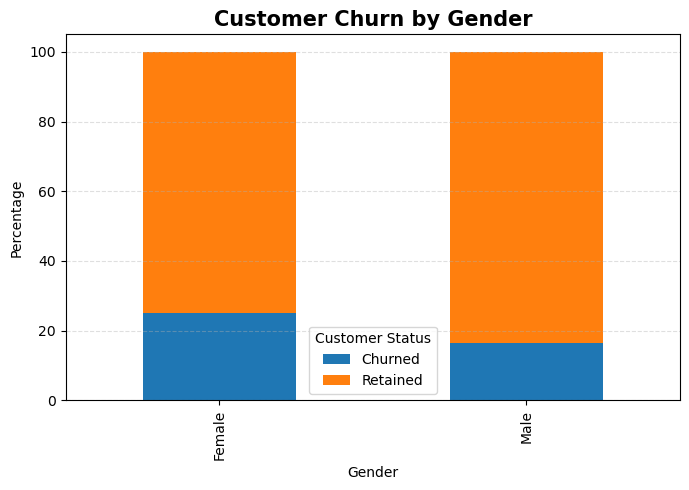

In [67]:
gender_pivot = (
    gender_churn_summary
    .pivot(
        index="Gender",
        columns="Churn_Status",
        values="Percentage"
    )
)

fig, ax = plt.subplots(figsize=(7,5))

gender_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Customer Churn by Gender",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Gender")
ax.set_ylabel("Percentage")

ax.legend(title="Customer Status")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "18_gender_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
gender_kpis = (
    df.groupby("Gender")
    .agg(
        Customers=("CustomerId","count"),
        Average_Age=("Age","mean"),
        Average_CreditScore=("CreditScore","mean"),
        Average_Balance=("Balance","mean"),
        Average_Tenure=("Tenure","mean"),
        Average_Salary=("EstimatedSalary","mean"),
        Active_Rate=("IsActiveMember","mean"),
        Churn_Rate=("Exited","mean")
    )
    .reset_index()
)

gender_kpis["Active_Rate"] = (
    gender_kpis["Active_Rate"] * 100
).round(2)

gender_kpis["Churn_Rate"] = (
    gender_kpis["Churn_Rate"] * 100
).round(2)

gender_kpis = gender_kpis.round(2)

gender_kpis

,Gender,Customers,Average_Age,Average_CreditScore,Average_Balance,Average_Tenure,Average_Salary,Active_Rate,Churn_Rate
0,Female,4543,39.24,650.83,"75,659.37",4.97,"100,601.54",50.28,25.07
1,Male,5457,38.66,650.28,"77,173.97",5.05,"99,664.58",52.54,16.46


In [69]:
gender_kpis.to_csv(
    table_directory /
    "gender_kpis.csv",
    index=False
)

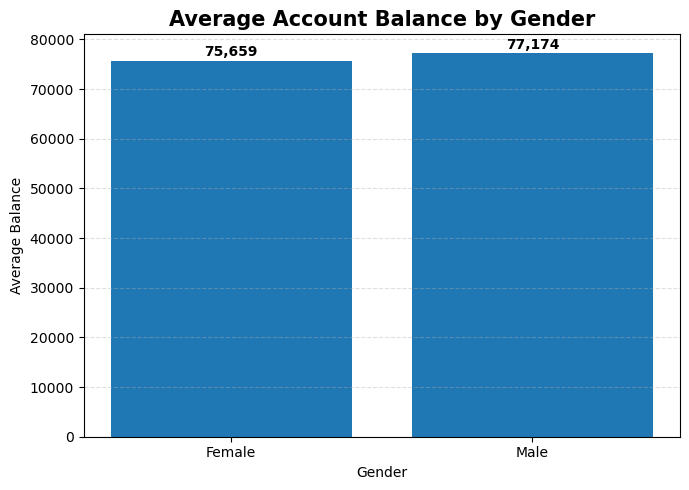

In [70]:
balance_gender = (
    df.groupby("Gender")["Balance"]
    .mean()
)

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    balance_gender.index,
    balance_gender.values
)

ax.set_title(
    "Average Account Balance by Gender",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Gender")
ax.set_ylabel("Average Balance")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    balance_gender.values
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+1000,
        f"{value:,.0f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "19_average_balance_by_gender.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gender Analysis Findings

- Male customers account for **54.57%** of the customer base, while female customers represent **45.43%**.
- **Female customers** exhibit the higher churn rate (**25.07%**), compared with **16.46%** for male customers.
- The difference in churn between genders is **significant**, indicating that gender is a **moderately strong** demographic predictor of customer churn.
- Female customers are slightly older on average (**39.24 years**) than male customers (**38.66 years**).
- Male customers maintain slightly higher average account balances (**77,173.97**) than female customers (**75,659.37**).
- Customer tenure, estimated salary, and credit scores are relatively similar across both genders, suggesting that these factors alone do not explain the observed churn difference.
- The active customer rate is slightly higher among male customers (**52.54%**) than female customers (**50.28%**), which may contribute to improved customer retention.
- Gender should be considered alongside age, geography, customer activity, and financial behaviour when developing customer-retention strategies and predictive machine learning models.

## 3.58 Customer Tenure Analysis

Customer tenure represents the number of years a customer has maintained a relationship with the bank. It is commonly used as an indicator of customer loyalty and long-term engagement.

This section analyses:

- Customer distribution across tenure levels
- Customer churn across tenure groups
- Customer loyalty patterns
- Business insights related to long-term customer retention

In [71]:
tenure_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],
    "Value": [
        df["Tenure"].min(),
        df["Tenure"].max(),
        round(df["Tenure"].mean(),2),
        round(df["Tenure"].median(),2),
        round(df["Tenure"].std(),2)
    ]
})

tenure_summary

,Statistic,Value
0,Minimum,0.00
1,Maximum,10.00
2,Mean,5.01
3,Median,5.00
4,Standard Deviation,2.89


In [72]:
tenure_summary.to_csv(
    table_directory /
    "tenure_summary.csv",
    index=False
)

In [73]:
tenure_distribution = (
    df["Tenure"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tenure_distribution.columns = [
    "Tenure_Years",
    "Customers"
]

tenure_distribution["Percentage"] = (
    tenure_distribution["Customers"]
    / len(df)
    *100
).round(2)

tenure_distribution

,Tenure_Years,Customers,Percentage
0,0,413,4.13
1,1,1035,10.35
2,2,1048,10.48
3,3,1009,10.09
4,4,989,9.89
5,5,1012,10.12
6,6,967,9.67
7,7,1028,10.28
8,8,1025,10.25
9,9,984,9.84


In [74]:
tenure_distribution.to_csv(
    table_directory /
    "tenure_distribution.csv",
    index=False
)

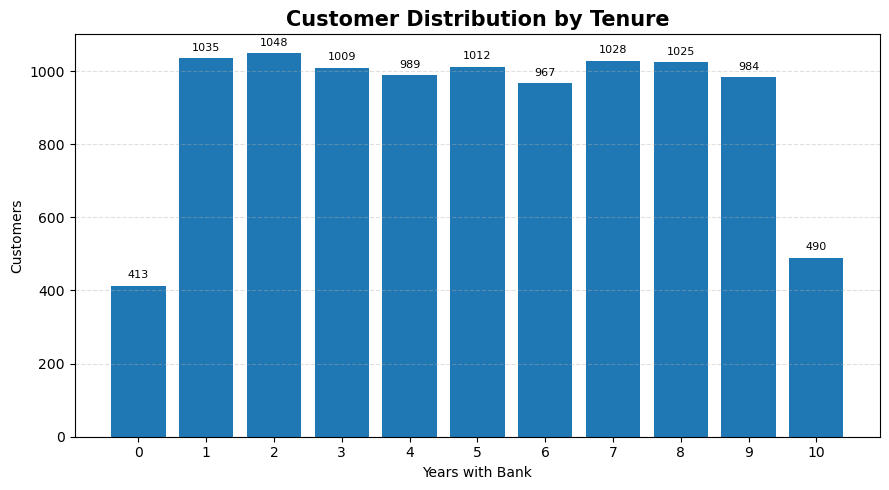

In [75]:
fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    tenure_distribution["Tenure_Years"].astype(str),
    tenure_distribution["Customers"]
)

ax.set_title(
    "Customer Distribution by Tenure",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Years with Bank")
ax.set_ylabel("Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    tenure_distribution["Customers"]
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+20,
        f"{value}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    chart_directory /
    "20_tenure_distribution.png",
    dpi=300
)

plt.show()

In [76]:
tenure_bins = [
    -1,
    2,
    5,
    8,
    10
]

tenure_labels = [
    "New",
    "Regular",
    "Loyal",
    "Long-Term"
]

df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

In [77]:
tenure_group_summary = (
    df["TenureGroup"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tenure_group_summary.columns = [
    "Tenure_Group",
    "Customers"
]

tenure_group_summary["Percentage"] = (
    tenure_group_summary["Customers"]
    / len(df)
    *100
).round(2)

tenure_group_summary

,Tenure_Group,Customers,Percentage
0,New,2496,24.96
1,Regular,3010,30.10
2,Loyal,3020,30.20
3,Long-Term,1474,14.74


In [78]:
tenure_group_summary.to_csv(
    table_directory /
    "tenure_group_summary.csv",
    index=False
)

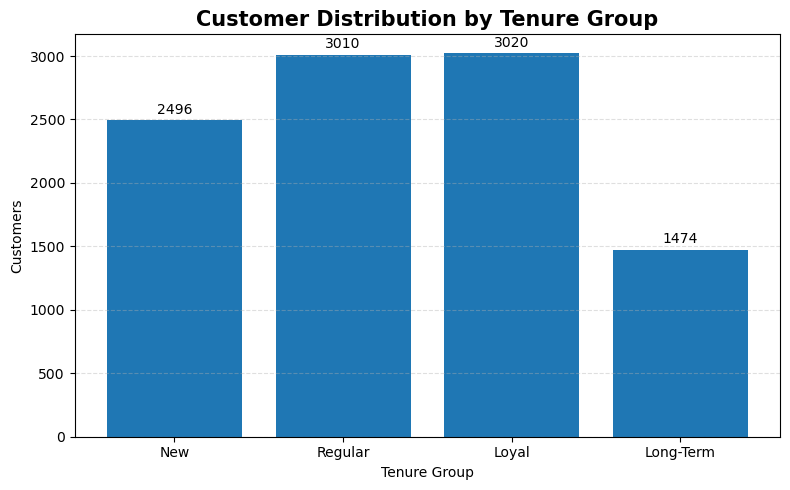

In [79]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    tenure_group_summary["Tenure_Group"],
    tenure_group_summary["Customers"]
)

ax.set_title(
    "Customer Distribution by Tenure Group",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Tenure Group")
ax.set_ylabel("Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    tenure_group_summary["Customers"]
):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        value+50,
        f"{value}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    chart_directory /
    "21_tenure_group_distribution.png",
    dpi=300
)

plt.show()

In [80]:
tenure_churn_summary = (
    df.groupby(
        ["TenureGroup","Churn_Status"],
        observed=False
    )
    .size()
    .reset_index(name="Customers")
)

tenure_churn_summary["Percentage"] = (
    tenure_churn_summary
    .groupby("TenureGroup")["Customers"]
    .transform(
        lambda x: x/x.sum()*100
    )
).round(2)

tenure_churn_summary

,TenureGroup,Churn_Status,Customers,Percentage
0,New,Churned,528,21.15
1,New,Retained,1968,78.85
2,Regular,Churned,625,20.76
3,Regular,Retained,2385,79.24
4,Loyal,Churned,570,18.87
5,Loyal,Retained,2450,81.13
6,Long-Term,Churned,314,21.30
7,Long-Term,Retained,1160,78.70


In [81]:
tenure_churn_summary.to_csv(
    table_directory /
    "tenure_churn_summary.csv",
    index=False
)

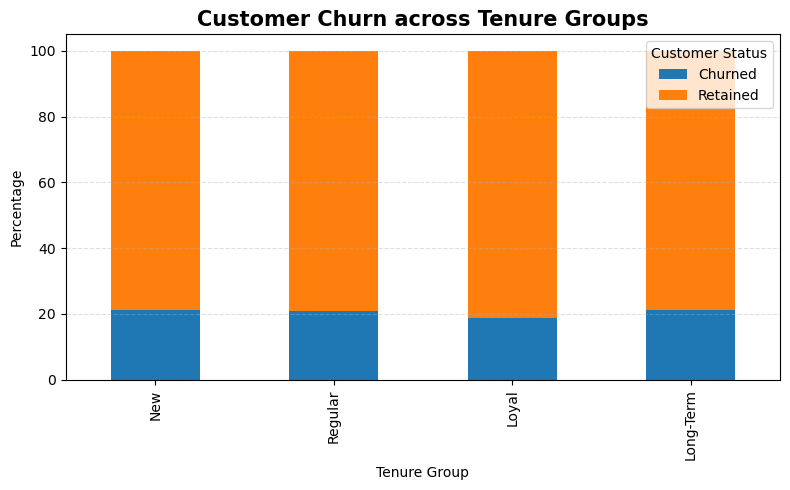

In [82]:
tenure_pivot = (
    tenure_churn_summary
    .pivot(
        index="TenureGroup",
        columns="Churn_Status",
        values="Percentage"
    )
)

fig, ax = plt.subplots(figsize=(8,5))

tenure_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Customer Churn across Tenure Groups",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Tenure Group")
ax.set_ylabel("Percentage")

ax.legend(title="Customer Status")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    chart_directory /
    "22_tenure_vs_churn.png",
    dpi=300
)

plt.show()

In [83]:
tenure_kpis = (
    df.groupby("TenureGroup")
    .agg(
        Customers=("CustomerId","count"),
        Average_Age=("Age","mean"),
        Average_Balance=("Balance","mean"),
        Average_CreditScore=("CreditScore","mean"),
        Average_Salary=("EstimatedSalary","mean"),
        Active_Rate=("IsActiveMember","mean"),
        Churn_Rate=("Exited","mean")
    )
    .reset_index()
)

tenure_kpis["Active_Rate"] *=100
tenure_kpis["Churn_Rate"] *=100

tenure_kpis = tenure_kpis.round(2)

tenure_kpis

,TenureGroup,Customers,Average_Age,Average_Balance,Average_CreditScore,Average_Salary,Active_Rate,Churn_Rate
0,New,2496,39.23,"78,053.98",651.03,"99,878.64",54.01,21.15
1,Regular,3010,38.86,"76,070.91",650.85,"99,606.94",50.83,20.76
2,Loyal,3020,38.55,"75,993.61",648.26,"100,525.67",51.42,18.87
3,Long-Term,1474,39.28,"75,686.58",653.66,"100,543.38",48.85,21.30


In [84]:
tenure_kpis.to_csv(
    table_directory /
    "tenure_kpis.csv",
    index=False
)

## Tenure Analysis Findings

- The largest customer segment belongs to the **Loyal (6–8 years)** tenure group, representing **30.20%** of all customers, closely followed by the **Regular (3–5 years)** group at **30.10%**.
- Customer churn remains relatively stable across all tenure groups, ranging from **18.87%** to **21.30%**.
- The **Long-Term** customer group exhibits the highest churn rate (**21.30%**), while the **Loyal** group records the lowest churn rate (**18.87%**).
- New customers also show a relatively high churn rate (**21.15%**), indicating that churn occurs both during the early stages of the customer relationship and among long-standing customers.
- Differences in churn rates across tenure groups are modest compared with the much larger differences observed for age and geography.
- Customer tenure appears to be a **moderate** predictor of churn rather than a dominant factor.
- Banks should implement retention strategies throughout the customer lifecycle instead of focusing exclusively on either new or long-term customers.

## 3.69 Customer Balance and High-Value Customer Analysis

Account balance represents the financial value maintained by a customer with the bank. Analysing balance patterns helps determine whether churn is concentrated among low-value, zero-balance, or high-value customers.

This section examines:

- Overall account-balance distribution
- Zero-balance customer behaviour
- Balance-based customer segments
- Churn rates across balance segments
- High-value customer churn
- Financial exposure associated with customer exits

In [85]:
balance_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation",
        "Q1",
        "Q3",
        "Zero-Balance Customers"
    ],
    "Value": [
        df["Balance"].min(),
        df["Balance"].max(),
        round(df["Balance"].mean(), 2),
        round(df["Balance"].median(), 2),
        round(df["Balance"].std(), 2),
        round(df["Balance"].quantile(0.25), 2),
        round(df["Balance"].quantile(0.75), 2),
        int((df["Balance"] == 0).sum())
    ]
})

balance_summary

,Statistic,Value
0,Minimum,0.00
1,Maximum,"250,898.09"
2,Mean,"76,485.89"
3,Median,"97,198.54"
4,Standard Deviation,"62,397.41"
5,Q1,0.00
6,Q3,"127,644.24"
7,Zero-Balance Customers,"3,617.00"


In [86]:
balance_summary.to_csv(
    table_directory / "balance_summary.csv",
    index=False
)

print("Balance summary saved successfully.")

Balance summary saved successfully.


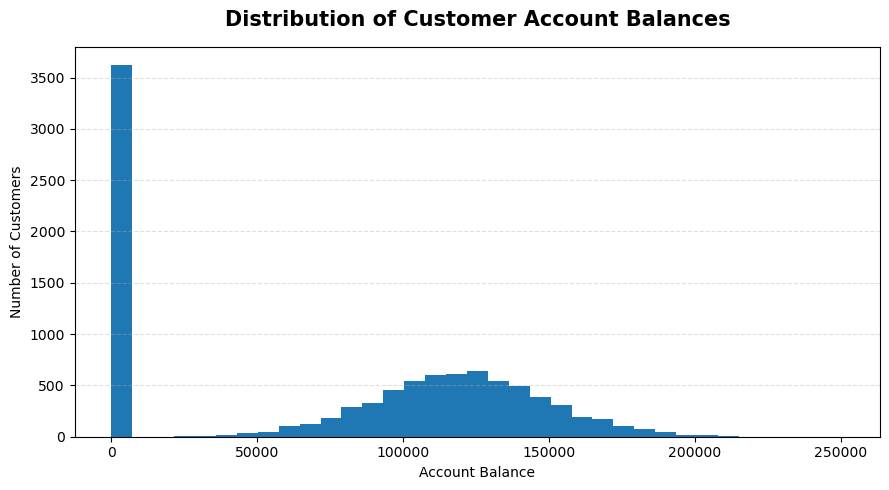

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\23_account_balance_distribution.png


In [87]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df["Balance"],
    bins=35
)

ax.set_title(
    "Distribution of Customer Account Balances",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Account Balance")
ax.set_ylabel("Number of Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "23_account_balance_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

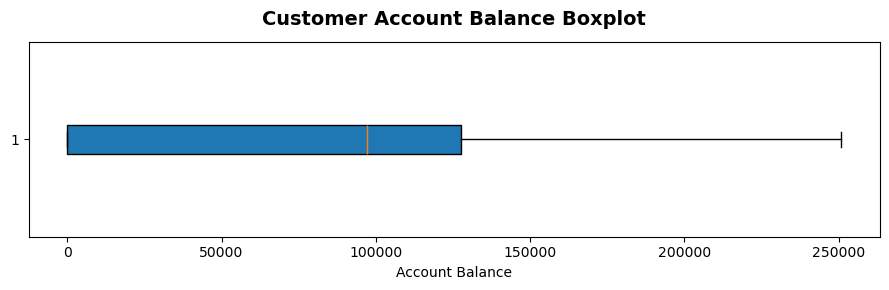

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\24_account_balance_boxplot.png


In [88]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.boxplot(
    df["Balance"],
    vert=False,
    patch_artist=True
)

ax.set_title(
    "Customer Account Balance Boxplot",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Account Balance")

plt.tight_layout()

chart_path = (
    chart_directory /
    "24_account_balance_boxplot.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [89]:
df["BalanceStatus"] = np.where(
    df["Balance"] == 0,
    "Zero Balance",
    "Positive Balance"
)

zero_balance_summary = (
    df.groupby("BalanceStatus")
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Average_Age=("Age", "mean"),
        Average_CreditScore=("CreditScore", "mean"),
        Average_Products=("NumOfProducts", "mean"),
        Active_Rate=("IsActiveMember", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

zero_balance_summary["Customer_Percentage"] = (
    zero_balance_summary["Customers"]
    / len(df)
    * 100
).round(2)

zero_balance_summary["Active_Rate"] = (
    zero_balance_summary["Active_Rate"] * 100
).round(2)

zero_balance_summary["Churn_Rate"] = (
    zero_balance_summary["Churn_Rate"] * 100
).round(2)

zero_balance_summary[
    [
        "Average_Age",
        "Average_CreditScore",
        "Average_Products"
    ]
] = zero_balance_summary[
    [
        "Average_Age",
        "Average_CreditScore",
        "Average_Products"
    ]
].round(2)

zero_balance_summary

,BalanceStatus,Customers,Churned_Customers,Average_Age,Average_CreditScore,Average_Products,Active_Rate,Churn_Rate,Customer_Percentage
0,Positive Balance,6383,1537,39.20,651.14,1.39,51.36,24.08,63.83
1,Zero Balance,3617,500,38.43,649.45,1.78,51.78,13.82,36.17


In [90]:
zero_balance_summary.to_csv(
    table_directory / "zero_balance_customer_summary.csv",
    index=False
)

print("Zero-balance customer summary saved.")

Zero-balance customer summary saved.


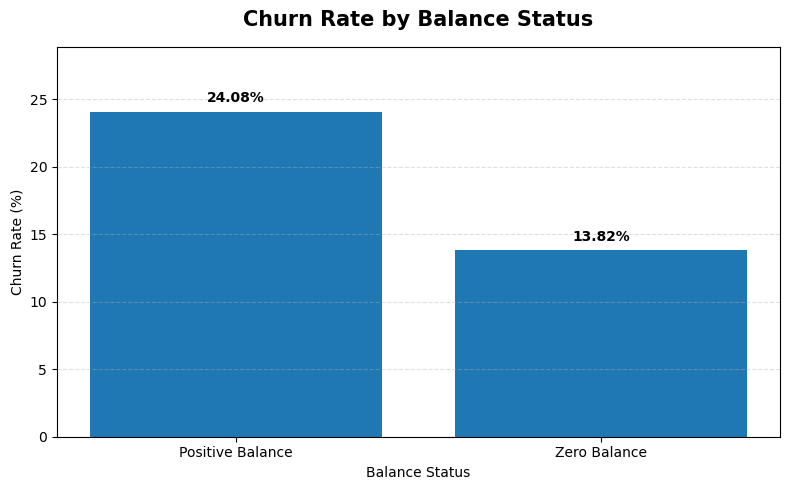

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\25_zero_balance_vs_churn.png


In [91]:
zero_balance_plot = (
    zero_balance_summary
    .set_index("BalanceStatus")
    ["Churn_Rate"]
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    zero_balance_plot.index,
    zero_balance_plot.values
)

ax.set_title(
    "Churn Rate by Balance Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Balance Status")
ax.set_ylabel("Churn Rate (%)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    zero_balance_plot.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    zero_balance_plot.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "25_zero_balance_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [92]:
positive_balance_customers = df.loc[
    df["Balance"] > 0,
    "Balance"
]

positive_balance_q1 = (
    positive_balance_customers.quantile(0.25)
)

positive_balance_median = (
    positive_balance_customers.quantile(0.50)
)

positive_balance_q3 = (
    positive_balance_customers.quantile(0.75)
)

print(
    f"Positive-balance Q1     : "
    f"{positive_balance_q1:,.2f}"
)

print(
    f"Positive-balance median : "
    f"{positive_balance_median:,.2f}"
)

print(
    f"Positive-balance Q3     : "
    f"{positive_balance_q3:,.2f}"
)

Positive-balance Q1     : 100,181.98
Positive-balance median : 119,839.69
Positive-balance Q3     : 139,512.29


In [93]:
def assign_balance_segment(balance):
    if balance == 0:
        return "Zero Balance"
    elif balance <= positive_balance_q1:
        return "Low Balance"
    elif balance <= positive_balance_median:
        return "Medium Balance"
    elif balance <= positive_balance_q3:
        return "High Balance"
    else:
        return "Premium Balance"


df["BalanceSegment"] = (
    df["Balance"].apply(assign_balance_segment)
)

balance_segment_order = [
    "Zero Balance",
    "Low Balance",
    "Medium Balance",
    "High Balance",
    "Premium Balance"
]

df["BalanceSegment"] = pd.Categorical(
    df["BalanceSegment"],
    categories=balance_segment_order,
    ordered=True
)

print("Balance segments created successfully.")

Balance segments created successfully.


In [94]:
balance_segment_summary = (
    df.groupby(
        "BalanceSegment",
        observed=False
    )
    .agg(
        Customers=("CustomerId", "count"),
        Minimum_Balance=("Balance", "min"),
        Maximum_Balance=("Balance", "max"),
        Average_Balance=("Balance", "mean")
    )
    .reset_index()
)

balance_segment_summary["Percentage"] = (
    balance_segment_summary["Customers"]
    / len(df)
    * 100
).round(2)

balance_segment_summary[
    [
        "Minimum_Balance",
        "Maximum_Balance",
        "Average_Balance"
    ]
] = balance_segment_summary[
    [
        "Minimum_Balance",
        "Maximum_Balance",
        "Average_Balance"
    ]
].round(2)

balance_segment_summary

,BalanceSegment,Customers,Minimum_Balance,Maximum_Balance,Average_Balance,Percentage
0,Zero Balance,3617,0.00,0.00,0.00,36.17
1,Low Balance,1596,"3,768.69","100,169.51","81,901.67",15.96
2,Medium Balance,1596,"100,194.44","119,839.69","110,269.28",15.96
3,High Balance,1595,"119,852.01","139,496.35","129,148.73",15.95
4,Premium Balance,1596,"139,528.23","250,898.09","157,996.13",15.96


In [95]:
balance_segment_summary.to_csv(
    table_directory / "balance_segment_summary.csv",
    index=False
)

print("Balance segment summary saved.")

Balance segment summary saved.


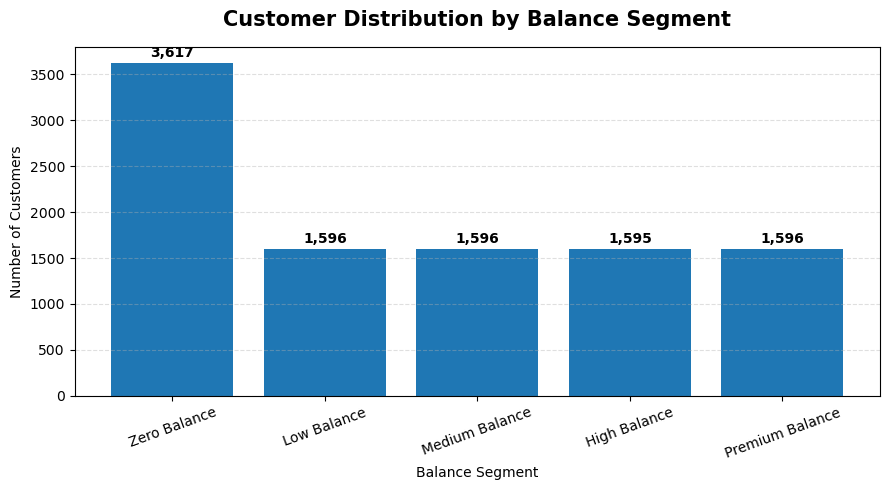

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\26_balance_segment_distribution.png


In [96]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    balance_segment_summary["BalanceSegment"],
    balance_segment_summary["Customers"]
)

ax.set_title(
    "Customer Distribution by Balance Segment",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Balance Segment")
ax.set_ylabel("Number of Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.tick_params(
    axis="x",
    rotation=20
)

for bar, value in zip(
    bars,
    balance_segment_summary["Customers"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 40,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "26_balance_segment_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [97]:
balance_churn_summary = (
    df.groupby(
        ["BalanceSegment", "Churn_Status"],
        observed=False
    )
    .size()
    .reset_index(name="Customers")
)

balance_churn_summary["Percentage"] = (
    balance_churn_summary
    .groupby("BalanceSegment")["Customers"]
    .transform(
        lambda values:
        values / values.sum() * 100
    )
).round(2)

balance_churn_summary

,BalanceSegment,Churn_Status,Customers,Percentage
0,Zero Balance,Churned,500,13.82
1,Zero Balance,Retained,3117,86.18
2,Low Balance,Churned,329,20.61
3,Low Balance,Retained,1267,79.39
4,Medium Balance,Churned,437,27.38
5,Medium Balance,Retained,1159,72.62
6,High Balance,Churned,404,25.33
7,High Balance,Retained,1191,74.67
8,Premium Balance,Churned,367,22.99
9,Premium Balance,Retained,1229,77.01


In [98]:
balance_churn_summary.to_csv(
    table_directory /
    "balance_segment_churn_summary.csv",
    index=False
)

print("Balance-segment churn summary saved.")

Balance-segment churn summary saved.


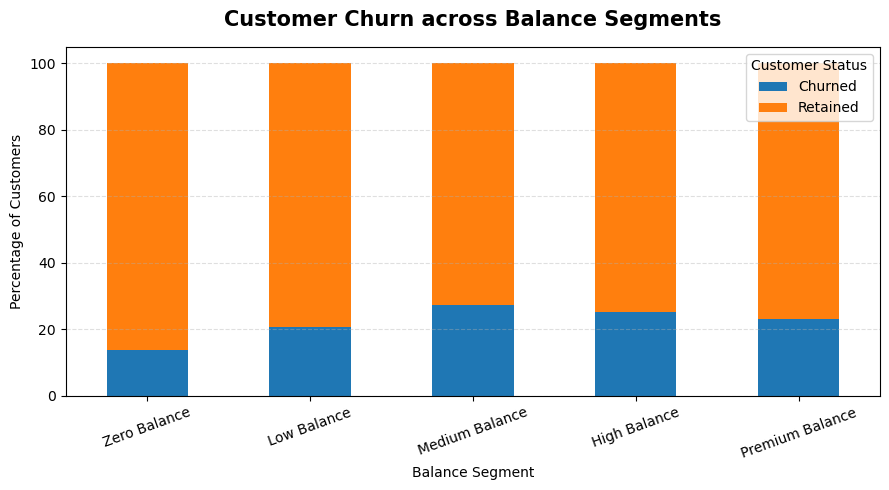

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\27_balance_segment_vs_churn.png


In [99]:
balance_churn_pivot = (
    balance_churn_summary
    .pivot(
        index="BalanceSegment",
        columns="Churn_Status",
        values="Percentage"
    )
    .reindex(balance_segment_order)
)

fig, ax = plt.subplots(figsize=(9, 5))

balance_churn_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Customer Churn across Balance Segments",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Balance Segment")
ax.set_ylabel("Percentage of Customers")

ax.legend(
    title="Customer Status"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.tick_params(
    axis="x",
    rotation=20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "27_balance_segment_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [100]:
balance_segment_kpis = (
    df.groupby(
        "BalanceSegment",
        observed=False
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Average_Age=("Age", "mean"),
        Average_Balance=("Balance", "mean"),
        Average_CreditScore=("CreditScore", "mean"),
        Average_Products=("NumOfProducts", "mean"),
        Average_Salary=("EstimatedSalary", "mean"),
        Active_Rate=("IsActiveMember", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

balance_segment_kpis["Active_Rate"] = (
    balance_segment_kpis["Active_Rate"]
    * 100
).round(2)

balance_segment_kpis["Churn_Rate"] = (
    balance_segment_kpis["Churn_Rate"]
    * 100
).round(2)

columns_to_round = [
    "Average_Age",
    "Average_Balance",
    "Average_CreditScore",
    "Average_Products",
    "Average_Salary"
]

balance_segment_kpis[columns_to_round] = (
    balance_segment_kpis[columns_to_round]
    .round(2)
)

balance_segment_kpis

,BalanceSegment,Customers,Churned_Customers,Average_Age,Average_Balance,Average_CreditScore,Average_Products,Average_Salary,Active_Rate,Churn_Rate
0,Zero Balance,3617,500,38.43,0.00,649.45,1.78,"98,983.56",51.78,13.82
1,Low Balance,1596,329,39.20,"81,901.67",652.23,1.39,"100,600.13",52.44,20.61
2,Medium Balance,1596,437,39.30,"110,269.28",652.01,1.39,"100,731.28",51.32,27.38
3,High Balance,1595,404,39.44,"129,148.73",649.63,1.38,"101,222.84",50.78,25.33
4,Premium Balance,1596,367,38.84,"157,996.13",650.67,1.39,"100,315.49",50.88,22.99


In [101]:
balance_segment_kpis.to_csv(
    table_directory /
    "balance_segment_kpis.csv",
    index=False
)

print("Balance-segment KPIs saved.")

Balance-segment KPIs saved.


In [102]:
high_value_threshold = positive_balance_q3

df["HighValueCustomer"] = np.where(
    df["Balance"] > high_value_threshold,
    "High Value",
    "Standard Value"
)

high_value_summary = (
    df.groupby("HighValueCustomer")
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Total_Balance=("Balance", "sum"),
        Average_Balance=("Balance", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

high_value_summary["Churn_Rate"] = (
    high_value_summary["Churn_Rate"]
    * 100
).round(2)

high_value_summary[
    [
        "Total_Balance",
        "Average_Balance"
    ]
] = high_value_summary[
    [
        "Total_Balance",
        "Average_Balance"
    ]
].round(2)

high_value_summary

,HighValueCustomer,Customers,Churned_Customers,Total_Balance,Average_Balance,Churn_Rate
0,High Value,1596,367,"252,161,829.24","157,996.13",22.99
1,Standard Value,8404,1670,"512,697,063.64","61,006.31",19.87


In [103]:
high_value_customers = df[
    df["HighValueCustomer"] == "High Value"
]

high_value_customer_count = len(
    high_value_customers
)

high_value_churned_count = int(
    high_value_customers["Exited"].sum()
)

high_value_churn_ratio = (
    high_value_churned_count
    / high_value_customer_count
    * 100
)

share_of_all_churn_from_high_value = (
    high_value_churned_count
    / churned_customers
    * 100
)

balance_at_risk = (
    high_value_customers.loc[
        high_value_customers["Exited"] == 1,
        "Balance"
    ].sum()
)

print("=" * 65)
print("HIGH-VALUE CUSTOMER CHURN KPIs")
print("=" * 65)

print(
    f"High-value balance threshold : "
    f"{high_value_threshold:,.2f}"
)

print(
    f"High-value customers         : "
    f"{high_value_customer_count:,}"
)

print(
    f"Churned high-value customers : "
    f"{high_value_churned_count:,}"
)

print(
    f"High-value churn ratio       : "
    f"{high_value_churn_ratio:.2f}%"
)

print(
    f"Share of all churn from high-value customers: "
    f"{share_of_all_churn_from_high_value:.2f}%"
)

print(
    f"Balance associated with churned high-value customers: "
    f"{balance_at_risk:,.2f}"
)

HIGH-VALUE CUSTOMER CHURN KPIs
High-value balance threshold : 139,512.29
High-value customers         : 1,596
Churned high-value customers : 367
High-value churn ratio       : 22.99%
Share of all churn from high-value customers: 18.02%
Balance associated with churned high-value customers: 58,714,368.09


In [104]:
high_value_summary.to_csv(
    table_directory /
    "high_value_customer_summary.csv",
    index=False
)

high_value_kpi_summary = pd.DataFrame({
    "KPI": [
        "High-Value Balance Threshold",
        "High-Value Customers",
        "Churned High-Value Customers",
        "High-Value Churn Ratio",
        "Share of All Churn from High-Value Customers",
        "Balance Associated with Churned High-Value Customers"
    ],
    "Value": [
        round(high_value_threshold, 2),
        high_value_customer_count,
        high_value_churned_count,
        round(high_value_churn_ratio, 2),
        round(
            share_of_all_churn_from_high_value,
            2
        ),
        round(balance_at_risk, 2)
    ]
})

high_value_kpi_summary.to_csv(
    table_directory /
    "high_value_churn_kpis.csv",
    index=False
)

high_value_kpi_summary

,KPI,Value
0,High-Value Balance Threshold,"139,512.29"
1,High-Value Customers,"1,596.00"
2,Churned High-Value Customers,367.00
3,High-Value Churn Ratio,22.99
4,Share of All Churn from High-Value Customers,18.02
5,Balance Associated with Churned High-Value Cus...,"58,714,368.09"


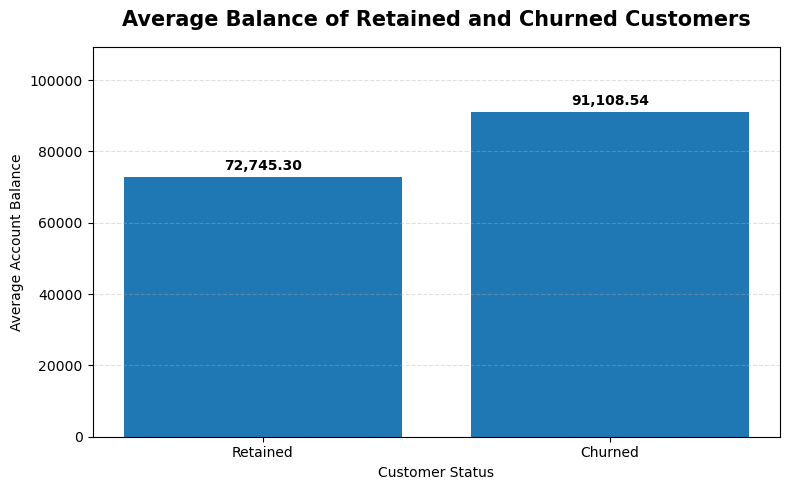

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\28_average_balance_by_churn_status.png


In [105]:
average_balance_churn = (
    df.groupby("Churn_Status")["Balance"]
    .mean()
    .reindex(["Retained", "Churned"])
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    average_balance_churn.index,
    average_balance_churn.values
)

ax.set_title(
    "Average Balance of Retained and Churned Customers",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Customer Status")
ax.set_ylabel("Average Account Balance")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    average_balance_churn.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1200,
        f"{value:,.2f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    average_balance_churn.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "28_average_balance_by_churn_status.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

## Balance and High-Value Customer Analysis Findings

- The average customer account balance is **76,485.89**, while the median balance is **97,198.54**.
- A total of **3,617 customers**, representing **36.17% of the customer base**, have a zero account balance.
- Customers in the **Medium Balance** segment exhibit the highest churn rate at **27.38%**.
- The churn rate among zero-balance customers is **13.82%**, compared with **24.08%** among customers with positive balances.
- Churned customers maintain an average balance of **91,108.54**, compared with **72,745.30** among retained customers.
- The high-value customer threshold is **139,512.29**, based on the upper quartile of positive customer balances.
- A total of **1,596 customers** are classified as high-value customers.
- High-value customers record a churn ratio of **22.99%**.
- A total of **367 high-value customers** churned, representing **18.02% of all churned customers**.
- The balance associated with churned high-value customers is **58,714,368.09**, representing a substantial financial-retention risk for the bank.
- Positive-balance customers show a considerably higher churn rate than zero-balance customers, indicating that customers with deeper financial relationships may also represent greater retention risk.
- Churn does not rise continuously with balance. The Medium Balance segment records the highest churn rate, followed by High Balance and Premium Balance customers.
- Account balance demonstrates an important but non-linear relationship with churn and should be used together with age, geography, activity status, and product usage in segmentation and predictive modelling.

## 3.85 Product Ownership and Customer Engagement Analysis

Customer relationships with a bank are influenced by the number of products they use, their activity level, and whether they own a credit card.

This section analyses:

- Customer distribution by number of products
- Churn across product-count groups
- Churn among active and inactive customers
- Churn by credit-card ownership
- Engagement-related banking KPIs
- Business implications for cross-selling and retention

In [106]:
product_summary = (
    df["NumOfProducts"]
    .value_counts()
    .sort_index()
    .reset_index()
)

product_summary.columns = [
    "Number_of_Products",
    "Customers"
]

product_summary["Percentage"] = (
    product_summary["Customers"]
    / len(df)
    * 100
).round(2)

product_summary

,Number_of_Products,Customers,Percentage
0,1,5084,50.84
1,2,4590,45.90
2,3,266,2.66
3,4,60,0.60


In [107]:
product_summary.to_csv(
    table_directory / "product_count_summary.csv",
    index=False
)

print("Product-count summary saved.")

Product-count summary saved.


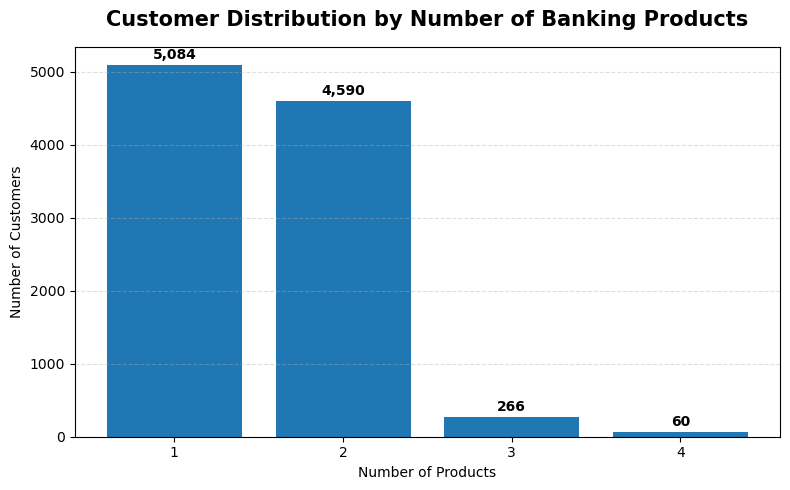

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\29_product_count_distribution.png


In [108]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    product_summary["Number_of_Products"].astype(str),
    product_summary["Customers"]
)

ax.set_title(
    "Customer Distribution by Number of Banking Products",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Products")
ax.set_ylabel("Number of Customers")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    product_summary["Customers"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 50,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "29_product_count_distribution.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [109]:
product_churn_summary = (
    df.groupby(
        ["NumOfProducts", "Churn_Status"],
        observed=False
    )
    .size()
    .reset_index(name="Customers")
)

product_churn_summary["Percentage"] = (
    product_churn_summary
    .groupby("NumOfProducts")["Customers"]
    .transform(
        lambda values:
        values / values.sum() * 100
    )
).round(2)

product_churn_summary

,NumOfProducts,Churn_Status,Customers,Percentage
0,1,Churned,1409,27.71
1,1,Retained,3675,72.29
2,2,Churned,348,7.58
3,2,Retained,4242,92.42
4,3,Churned,220,82.71
5,3,Retained,46,17.29
6,4,Churned,60,100.00


In [110]:
product_churn_summary.to_csv(
    table_directory /
    "product_count_churn_summary.csv",
    index=False
)

print("Product-count churn summary saved.")

Product-count churn summary saved.


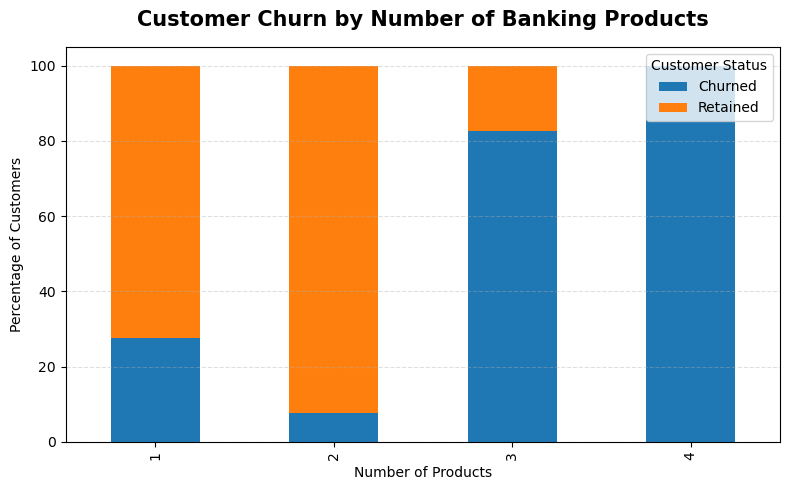

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\30_product_count_vs_churn.png


In [111]:
product_churn_pivot = (
    product_churn_summary
    .pivot(
        index="NumOfProducts",
        columns="Churn_Status",
        values="Percentage"
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

product_churn_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Customer Churn by Number of Banking Products",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Products")
ax.set_ylabel("Percentage of Customers")

ax.legend(
    title="Customer Status"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "30_product_count_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [112]:
product_kpis = (
    df.groupby("NumOfProducts")
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Average_Age=("Age", "mean"),
        Average_Balance=("Balance", "mean"),
        Average_CreditScore=("CreditScore", "mean"),
        Average_Tenure=("Tenure", "mean"),
        Average_Salary=("EstimatedSalary", "mean"),
        Active_Rate=("IsActiveMember", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

product_kpis["Active_Rate"] = (
    product_kpis["Active_Rate"] * 100
).round(2)

product_kpis["Churn_Rate"] = (
    product_kpis["Churn_Rate"] * 100
).round(2)

product_kpis[
    [
        "Average_Age",
        "Average_Balance",
        "Average_CreditScore",
        "Average_Tenure",
        "Average_Salary"
    ]
] = product_kpis[
    [
        "Average_Age",
        "Average_Balance",
        "Average_CreditScore",
        "Average_Tenure",
        "Average_Salary"
    ]
].round(2)

product_kpis

,NumOfProducts,Customers,Churned_Customers,Average_Age,Average_Balance,Average_CreditScore,Average_Tenure,Average_Salary,Active_Rate,Churn_Rate
0,1,5084,1409,39.67,"98,551.87",649.12,4.97,"99,487.26",50.41,27.71
1,2,4590,348,37.75,"51,879.15",652.19,5.05,"100,452.01",53.29,7.58
2,3,266,220,43.20,"75,458.33",648.11,5.00,"104,318.13",42.48,82.71
3,4,60,60,45.68,"93,733.14",653.58,5.30,"104,763.72",48.33,100.00


In [113]:
product_kpis.to_csv(
    table_directory /
    "product_count_kpis.csv",
    index=False
)

print("Product-count KPIs saved.")

Product-count KPIs saved.


In [114]:
activity_summary = (
    df.groupby("Activity_Status")
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Average_Age=("Age", "mean"),
        Average_Balance=("Balance", "mean"),
        Average_Products=("NumOfProducts", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

activity_summary["Customer_Percentage"] = (
    activity_summary["Customers"]
    / len(df)
    * 100
).round(2)

activity_summary["Churn_Rate"] = (
    activity_summary["Churn_Rate"]
    * 100
).round(2)

activity_summary[
    [
        "Average_Age",
        "Average_Balance",
        "Average_Products"
    ]
] = activity_summary[
    [
        "Average_Age",
        "Average_Balance",
        "Average_Products"
    ]
].round(2)

activity_summary

,Activity_Status,Customers,Churned_Customers,Average_Age,Average_Balance,Average_Products,Churn_Rate,Customer_Percentage
0,Active,5151,735,39.79,"75,875.42",1.54,14.27,51.51
1,Inactive,4849,1302,38.00,"77,134.38",1.52,26.85,48.49


In [115]:
activity_summary.to_csv(
    table_directory /
    "activity_status_summary.csv",
    index=False
)

print("Activity-status summary saved.")

Activity-status summary saved.


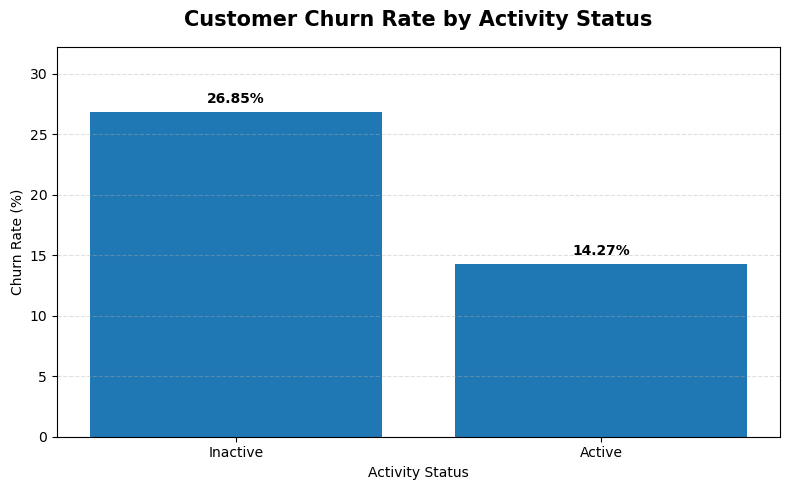

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\31_activity_status_vs_churn.png


In [116]:
activity_churn_rate = (
    activity_summary
    .set_index("Activity_Status")
    ["Churn_Rate"]
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    activity_churn_rate.index,
    activity_churn_rate.values
)

ax.set_title(
    "Customer Churn Rate by Activity Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Activity Status")
ax.set_ylabel("Churn Rate (%)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    activity_churn_rate.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    activity_churn_rate.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "31_activity_status_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [117]:
active_churn_rate = (
    df.loc[
        df["IsActiveMember"] == 1,
        "Exited"
    ].mean() * 100
)

inactive_churn_rate = (
    df.loc[
        df["IsActiveMember"] == 0,
        "Exited"
    ].mean() * 100
)

engagement_drop_indicator = (
    inactive_churn_rate
    - active_churn_rate
)

inactive_to_active_risk_ratio = (
    inactive_churn_rate
    / active_churn_rate
    if active_churn_rate != 0
    else np.nan
)

print("=" * 65)
print("ENGAGEMENT DROP INDICATOR")
print("=" * 65)

print(
    f"Active customer churn rate   : "
    f"{active_churn_rate:.2f}%"
)

print(
    f"Inactive customer churn rate : "
    f"{inactive_churn_rate:.2f}%"
)

print(
    f"Engagement drop indicator    : "
    f"{engagement_drop_indicator:.2f} percentage points"
)

print(
    f"Inactive-to-active churn risk ratio: "
    f"{inactive_to_active_risk_ratio:.2f}x"
)

ENGAGEMENT DROP INDICATOR
Active customer churn rate   : 14.27%
Inactive customer churn rate : 26.85%
Engagement drop indicator    : 12.58 percentage points
Inactive-to-active churn risk ratio: 1.88x


In [118]:
engagement_kpi_summary = pd.DataFrame({
    "KPI": [
        "Active Customer Churn Rate",
        "Inactive Customer Churn Rate",
        "Engagement Drop Indicator",
        "Inactive-to-Active Churn Risk Ratio"
    ],
    "Value": [
        round(active_churn_rate, 2),
        round(inactive_churn_rate, 2),
        round(engagement_drop_indicator, 2),
        round(inactive_to_active_risk_ratio, 2)
    ],
    "Unit": [
        "Percent",
        "Percent",
        "Percentage Points",
        "Ratio"
    ]
})

engagement_kpi_summary.to_csv(
    table_directory /
    "engagement_drop_indicator.csv",
    index=False
)

engagement_kpi_summary

,KPI,Value,Unit
0,Active Customer Churn Rate,14.27,Percent
1,Inactive Customer Churn Rate,26.85,Percent
2,Engagement Drop Indicator,12.58,Percentage Points
3,Inactive-to-Active Churn Risk Ratio,1.88,Ratio


In [119]:
credit_card_summary = (
    df.groupby("Credit_Card_Status")
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Average_Age=("Age", "mean"),
        Average_Balance=("Balance", "mean"),
        Average_Products=("NumOfProducts", "mean"),
        Active_Rate=("IsActiveMember", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

credit_card_summary["Customer_Percentage"] = (
    credit_card_summary["Customers"]
    / len(df)
    * 100
).round(2)

credit_card_summary["Active_Rate"] = (
    credit_card_summary["Active_Rate"]
    * 100
).round(2)

credit_card_summary["Churn_Rate"] = (
    credit_card_summary["Churn_Rate"]
    * 100
).round(2)

credit_card_summary[
    [
        "Average_Age",
        "Average_Balance",
        "Average_Products"
    ]
] = credit_card_summary[
    [
        "Average_Age",
        "Average_Balance",
        "Average_Products"
    ]
].round(2)

credit_card_summary

,Credit_Card_Status,Customers,Churned_Customers,Average_Age,Average_Balance,Average_Products,Active_Rate,Churn_Rate,Customer_Percentage
0,Has Credit Card,7055,1424,38.84,"75,886.91",1.53,51.13,20.18,70.55
1,No Credit Card,2945,613,39.11,"77,920.79",1.53,52.43,20.81,29.45


In [120]:
credit_card_summary.to_csv(
    table_directory /
    "credit_card_ownership_summary.csv",
    index=False
)

print("Credit-card ownership summary saved.")

Credit-card ownership summary saved.


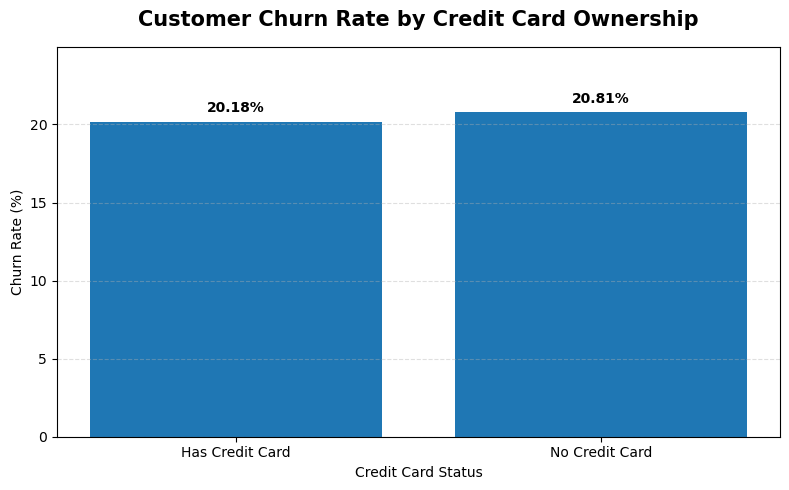

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\32_credit_card_ownership_vs_churn.png


In [121]:
credit_card_churn_rate = (
    credit_card_summary
    .set_index("Credit_Card_Status")
    ["Churn_Rate"]
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    credit_card_churn_rate.index,
    credit_card_churn_rate.values
)

ax.set_title(
    "Customer Churn Rate by Credit Card Ownership",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Credit Card Status")
ax.set_ylabel("Churn Rate (%)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    credit_card_churn_rate.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.4,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    credit_card_churn_rate.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "32_credit_card_ownership_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [122]:
def assign_engagement_segment(row):
    if (
        row["IsActiveMember"] == 1
        and row["NumOfProducts"] >= 2
    ):
        return "Highly Engaged"

    elif (
        row["IsActiveMember"] == 1
        or row["NumOfProducts"] >= 2
    ):
        return "Moderately Engaged"

    else:
        return "Low Engagement"


df["EngagementSegment"] = df.apply(
    assign_engagement_segment,
    axis=1
)

engagement_segment_order = [
    "Low Engagement",
    "Moderately Engaged",
    "Highly Engaged"
]

df["EngagementSegment"] = pd.Categorical(
    df["EngagementSegment"],
    categories=engagement_segment_order,
    ordered=True
)

engagement_segment_summary = (
    df.groupby(
        "EngagementSegment",
        observed=False
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Average_Products=("NumOfProducts", "mean"),
        Active_Rate=("IsActiveMember", "mean"),
        Average_Balance=("Balance", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

engagement_segment_summary["Active_Rate"] = (
    engagement_segment_summary["Active_Rate"]
    * 100
).round(2)

engagement_segment_summary["Churn_Rate"] = (
    engagement_segment_summary["Churn_Rate"]
    * 100
).round(2)

engagement_segment_summary[
    [
        "Average_Products",
        "Average_Balance"
    ]
] = engagement_segment_summary[
    [
        "Average_Products",
        "Average_Balance"
    ]
].round(2)

engagement_segment_summary

,EngagementSegment,Customers,Churned_Customers,Average_Products,Active_Rate,Average_Balance,Churn_Rate
0,Low Engagement,2521,924,1.00,0.00,"98,195.89",36.65
1,Moderately Engaged,4891,863,1.52,52.40,"77,685.27",17.64
2,Highly Engaged,2588,250,2.07,100.00,"53,071.26",9.66


In [123]:
engagement_segment_summary.to_csv(
    table_directory /
    "engagement_segment_summary.csv",
    index=False
)

print("Engagement-segment summary saved.")

Engagement-segment summary saved.


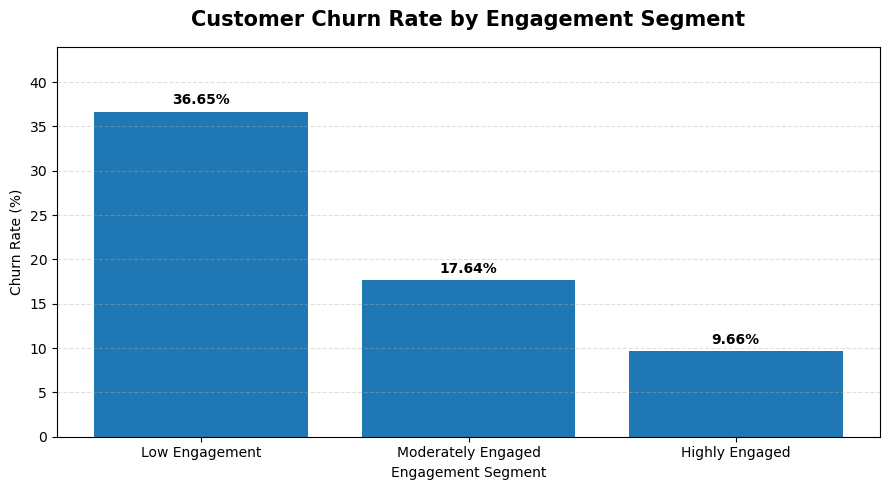

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\33_engagement_segment_vs_churn.png


In [124]:
engagement_segment_churn = (
    engagement_segment_summary
    .set_index("EngagementSegment")
    ["Churn_Rate"]
    .reindex(engagement_segment_order)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    engagement_segment_churn.index,
    engagement_segment_churn.values
)

ax.set_title(
    "Customer Churn Rate by Engagement Segment",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Engagement Segment")
ax.set_ylabel("Churn Rate (%)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    engagement_segment_churn.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    engagement_segment_churn.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "33_engagement_segment_vs_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

## Product Ownership and Engagement Analysis Findings

- Most customers hold **1 or 2 banking products**, with **50.84%** owning one product and **45.90%** owning two products.
- Customers holding **2 banking products** record the lowest churn rate (**7.58%**), indicating the strongest customer retention.
- Customers holding **4 banking products** record the highest churn rate (**100.00%**). However, this group contains only **60 customers (0.60%)**, so the finding should be interpreted cautiously.
- Among customer groups with meaningful sample sizes, customers holding **3 banking products** exhibit an exceptionally high churn rate (**82.71%**), suggesting that additional product ownership does not necessarily improve customer retention.
- Product ownership demonstrates a **non-linear** relationship with churn. Customers with two products are the most stable, while customers with one, three, or four products experience substantially higher churn.
- Active customers record a churn rate of **14.27%**, compared with **26.85%** among inactive customers.
- The **Engagement Drop Indicator** is **12.58 percentage points**.
- Inactive customers are approximately **1.88 times** more likely to churn than active customers.
- Credit-card ownership has a **very weak** relationship with churn because cardholders and non-cardholders record almost identical churn rates (**20.18%** and **20.81%**, respectively).
- The **Low Engagement** segment records the highest churn rate (**36.65%**), while the **Highly Engaged** segment records the lowest churn rate (**9.66%**).
- Customer activity and product usage are among the strongest behavioural indicators of churn and should play a central role in customer segmentation, predictive modelling, and retention strategy development.

## 3.99 Correlation and Multivariate Analysis

Univariate and bivariate analyses examine variables independently or in pairs. However, customer churn is usually influenced by multiple demographic, financial, and behavioural factors acting together.

This section analyses:

- Correlations among numerical variables
- Numerical relationships with the churn target
- Combined demographic and geographic churn patterns
- Interaction between activity, product usage, and customer value
- Key features to carry forward into machine learning

In [125]:
correlation_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

correlation_data = df[correlation_columns].copy()

print("Correlation dataset shape:", correlation_data.shape)
correlation_data.head()

Correlation dataset shape: (10000, 9)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,"101,348.88",1
1,608,41,1,"83,807.86",1,0,1,"112,542.58",0
2,502,42,8,"159,660.80",3,1,0,"113,931.57",1
3,699,39,1,0.00,2,0,0,"93,826.63",0
4,850,43,2,"125,510.82",1,1,1,"79,084.10",0


In [126]:
correlation_matrix = (
    correlation_data
    .corr()
    .round(3)
)

correlation_matrix

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.00,-0.00,0.00,0.01,0.01,-0.01,0.03,-0.00,-0.03
Age,-0.00,1.00,-0.01,0.03,-0.03,-0.01,0.09,-0.01,0.28
Tenure,0.00,-0.01,1.00,-0.01,0.01,0.02,-0.03,0.01,-0.01
Balance,0.01,0.03,-0.01,1.00,-0.30,-0.01,-0.01,0.01,0.12
NumOfProducts,0.01,-0.03,0.01,-0.30,1.00,0.00,0.01,0.01,-0.05
HasCrCard,-0.01,-0.01,0.02,-0.01,0.00,1.00,-0.01,-0.01,-0.01
IsActiveMember,0.03,0.09,-0.03,-0.01,0.01,-0.01,1.00,-0.01,-0.16
EstimatedSalary,-0.00,-0.01,0.01,0.01,0.01,-0.01,-0.01,1.00,0.01
Exited,-0.03,0.28,-0.01,0.12,-0.05,-0.01,-0.16,0.01,1.00


In [127]:
correlation_matrix.to_csv(
    table_directory /
    "numerical_correlation_matrix.csv"
)

print("Numerical correlation matrix saved.")

Numerical correlation matrix saved.


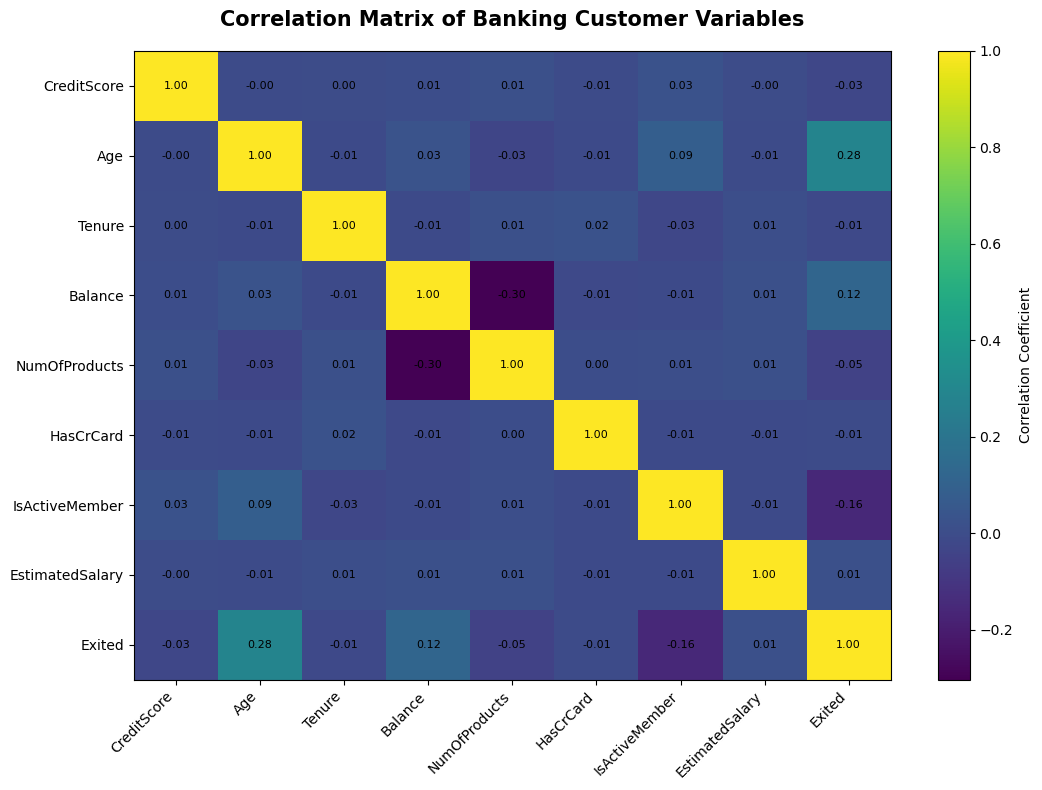

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\34_numerical_correlation_heatmap.png


In [128]:
fig, ax = plt.subplots(figsize=(11, 8))

heatmap = ax.imshow(
    correlation_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(correlation_matrix.columns))
)

ax.set_yticks(
    np.arange(len(correlation_matrix.index))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_matrix.index
)

for row_index in range(
    correlation_matrix.shape[0]
):
    for column_index in range(
        correlation_matrix.shape[1]
    ):
        value = correlation_matrix.iloc[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title(
    "Correlation Matrix of Banking Customer Variables",
    fontsize=15,
    fontweight="bold",
    pad=18
)

fig.colorbar(
    heatmap,
    ax=ax,
    label="Correlation Coefficient"
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "34_numerical_correlation_heatmap.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [129]:
churn_correlation = (
    correlation_matrix["Exited"]
    .drop("Exited")
    .sort_values(
        key=lambda values:
        values.abs(),
        ascending=False
    )
    .reset_index()
)

churn_correlation.columns = [
    "Feature",
    "Correlation_with_Churn"
]

churn_correlation["Absolute_Correlation"] = (
    churn_correlation[
        "Correlation_with_Churn"
    ].abs()
)

churn_correlation

,Feature,Correlation_with_Churn,Absolute_Correlation
0,Age,0.28,0.28
1,IsActiveMember,-0.16,0.16
2,Balance,0.12,0.12
3,NumOfProducts,-0.05,0.05
4,CreditScore,-0.03,0.03
5,Tenure,-0.01,0.01
6,EstimatedSalary,0.01,0.01
7,HasCrCard,-0.01,0.01


In [130]:
churn_correlation.to_csv(
    table_directory /
    "churn_correlation_ranking.csv",
    index=False
)

print("Churn-correlation ranking saved.")

Churn-correlation ranking saved.


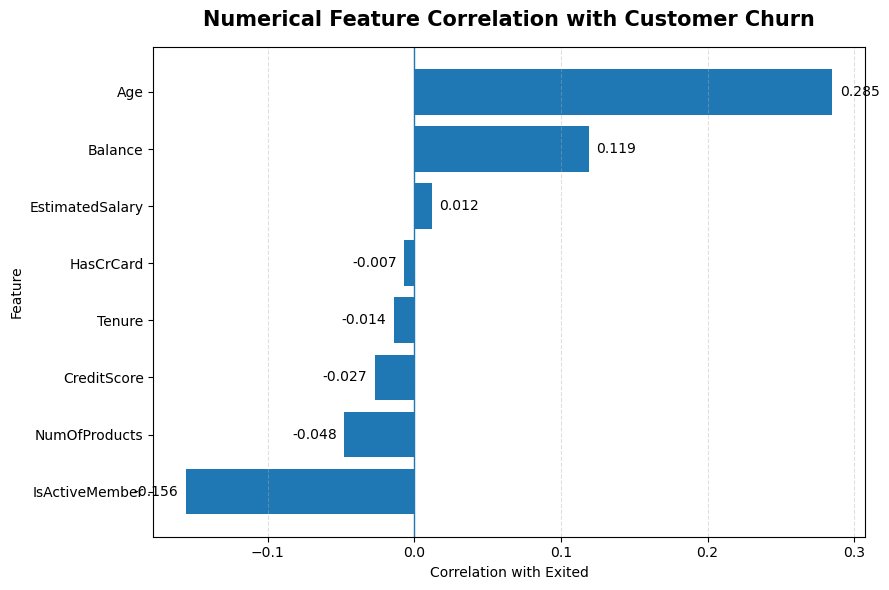

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\35_churn_correlation_ranking.png


In [131]:
correlation_plot_data = (
    churn_correlation
    .sort_values(
        by="Correlation_with_Churn"
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    correlation_plot_data["Feature"],
    correlation_plot_data[
        "Correlation_with_Churn"
    ]
)

ax.set_title(
    "Numerical Feature Correlation with Customer Churn",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Correlation with Exited")
ax.set_ylabel("Feature")

ax.axvline(
    0,
    linewidth=1
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    correlation_plot_data[
        "Correlation_with_Churn"
    ]
):
    horizontal_alignment = (
        "left"
        if value >= 0
        else "right"
    )

    text_offset = (
        0.005
        if value >= 0
        else -0.005
    )

    ax.text(
        value + text_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha=horizontal_alignment
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "35_churn_correlation_ranking.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [132]:
age_geography_churn = (
    df.groupby(
        ["Geography", "AgeGroup"],
        observed=False
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

age_geography_churn["Churn_Rate"] = (
    age_geography_churn["Churn_Rate"]
    * 100
).round(2)

age_geography_churn

,Geography,AgeGroup,Customers,Churned_Customers,Churn_Rate
0,France,18-30,1038,51,4.91
1,France,31-40,2311,220,9.52
2,France,41-50,1067,300,28.12
3,France,51-60,367,193,52.59
4,France,60+,231,46,19.91
5,Germany,18-30,453,56,12.36
6,Germany,31-40,1022,214,20.94
7,Germany,41-50,678,331,48.82
8,Germany,51-60,243,169,69.55
9,Germany,60+,113,44,38.94


In [133]:
age_geography_churn.to_csv(
    table_directory /
    "age_geography_churn_summary.csv",
    index=False
)

print("Age-geography churn summary saved.")

Age-geography churn summary saved.


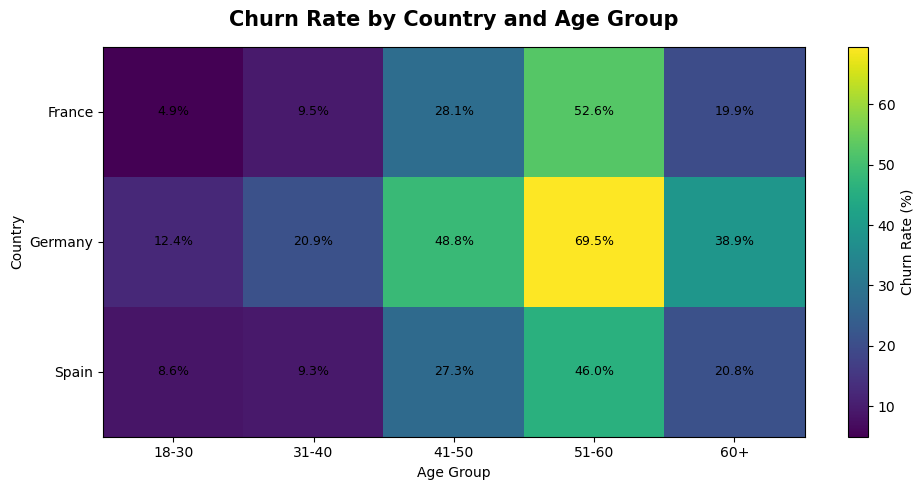

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\36_country_age_group_churn_heatmap.png


In [134]:
age_geography_pivot = (
    age_geography_churn
    .pivot(
        index="Geography",
        columns="AgeGroup",
        values="Churn_Rate"
    )
    .reindex(
        columns=[
            "18-30",
            "31-40",
            "41-50",
            "51-60",
            "60+"
        ]
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

heatmap = ax.imshow(
    age_geography_pivot.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(age_geography_pivot.columns)
    )
)

ax.set_yticks(
    np.arange(
        len(age_geography_pivot.index)
    )
)

ax.set_xticklabels(
    age_geography_pivot.columns
)

ax.set_yticklabels(
    age_geography_pivot.index
)

for row_index in range(
    age_geography_pivot.shape[0]
):
    for column_index in range(
        age_geography_pivot.shape[1]
    ):
        value = age_geography_pivot.iloc[
            row_index,
            column_index
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title(
    "Churn Rate by Country and Age Group",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Country")

fig.colorbar(
    heatmap,
    ax=ax,
    label="Churn Rate (%)"
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "36_country_age_group_churn_heatmap.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [135]:
gender_geography_churn = (
    df.groupby(
        ["Geography", "Gender"],
        observed=False
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

gender_geography_churn["Churn_Rate"] = (
    gender_geography_churn["Churn_Rate"]
    * 100
).round(2)

gender_geography_churn

,Geography,Gender,Customers,Churned_Customers,Churn_Rate
0,France,Female,2261,460,20.34
1,France,Male,2753,350,12.71
2,Germany,Female,1193,448,37.55
3,Germany,Male,1316,366,27.81
4,Spain,Female,1089,231,21.21
5,Spain,Male,1388,182,13.11


In [136]:
gender_geography_churn.to_csv(
    table_directory /
    "gender_geography_churn_summary.csv",
    index=False
)

print("Gender-geography churn summary saved.")

Gender-geography churn summary saved.


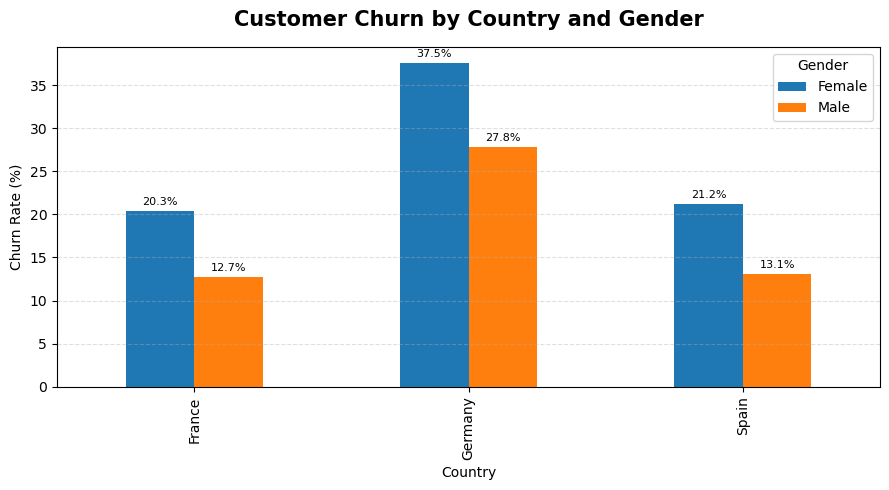

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\37_country_gender_churn.png


In [137]:
gender_geography_pivot = (
    gender_geography_churn
    .pivot(
        index="Geography",
        columns="Gender",
        values="Churn_Rate"
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

gender_geography_pivot.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Customer Churn by Country and Gender",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Country")
ax.set_ylabel("Churn Rate (%)")

ax.legend(
    title="Gender"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for container_item in ax.containers:
    ax.bar_label(
        container_item,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "37_country_gender_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [138]:
product_activity_churn = (
    df.groupby(
        [
            "NumOfProducts",
            "Activity_Status"
        ],
        observed=False
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

product_activity_churn["Churn_Rate"] = (
    product_activity_churn["Churn_Rate"]
    * 100
).round(2)

product_activity_churn

,NumOfProducts,Activity_Status,Customers,Churned_Customers,Churn_Rate
0,1,Active,2563,485,18.92
1,1,Inactive,2521,924,36.65
2,2,Active,2446,136,5.56
3,2,Inactive,2144,212,9.89
4,3,Active,113,85,75.22
5,3,Inactive,153,135,88.24
6,4,Active,29,29,100.00
7,4,Inactive,31,31,100.00


In [139]:
product_activity_churn.to_csv(
    table_directory /
    "product_activity_churn_summary.csv",
    index=False
)

print("Product-activity churn summary saved.")

Product-activity churn summary saved.


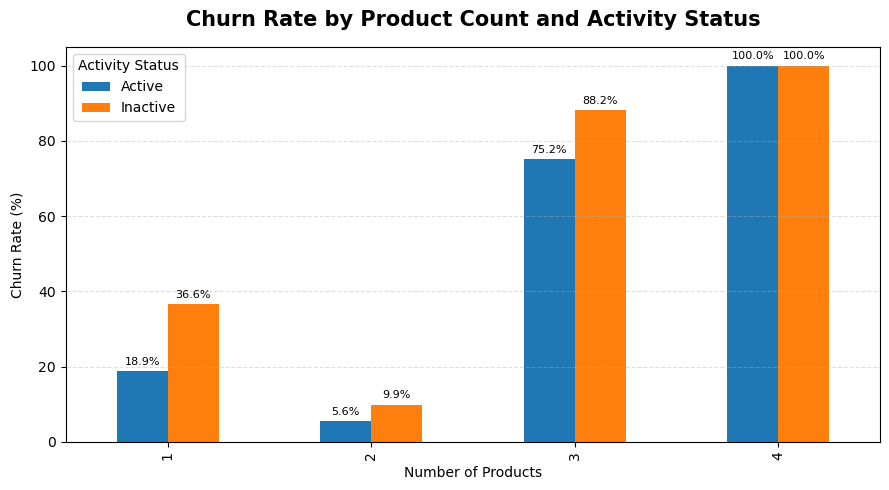

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\38_product_activity_churn.png


In [140]:
product_activity_pivot = (
    product_activity_churn
    .pivot(
        index="NumOfProducts",
        columns="Activity_Status",
        values="Churn_Rate"
    )
)

fig, ax = plt.subplots(figsize=(9, 5))

product_activity_pivot.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Churn Rate by Product Count and Activity Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Number of Products")
ax.set_ylabel("Churn Rate (%)")

ax.legend(
    title="Activity Status"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for container_item in ax.containers:
    ax.bar_label(
        container_item,
        fmt="%.1f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()

chart_path = (
    chart_directory /
    "38_product_activity_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [141]:
high_risk_conditions = (
    (df["Geography"] == "Germany")
    | (df["AgeGroup"].isin(["41-50", "51-60"]))
    | (df["EngagementSegment"] == "Low Engagement")
    | (df["NumOfProducts"] >= 3)
)

df["EDA_Risk_Segment"] = np.where(
    high_risk_conditions,
    "Higher Observed Risk",
    "Lower Observed Risk"
)

eda_risk_summary = (
    df.groupby("EDA_Risk_Segment")
    .agg(
        Customers=("CustomerId", "count"),
        Churned_Customers=("Exited", "sum"),
        Average_Age=("Age", "mean"),
        Average_Balance=("Balance", "mean"),
        Active_Rate=("IsActiveMember", "mean"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

eda_risk_summary["Customer_Percentage"] = (
    eda_risk_summary["Customers"]
    / len(df)
    * 100
).round(2)

eda_risk_summary["Active_Rate"] = (
    eda_risk_summary["Active_Rate"]
    * 100
).round(2)

eda_risk_summary["Churn_Rate"] = (
    eda_risk_summary["Churn_Rate"]
    * 100
).round(2)

eda_risk_summary[
    [
        "Average_Age",
        "Average_Balance"
    ]
] = eda_risk_summary[
    [
        "Average_Age",
        "Average_Balance"
    ]
].round(2)

eda_risk_summary

,EDA_Risk_Segment,Customers,Churned_Customers,Average_Age,Average_Balance,Active_Rate,Churn_Rate,Customer_Percentage
0,Higher Observed Risk,5987,1818,41.31,"92,615.80",40.52,30.37,59.87
1,Lower Observed Risk,4013,219,35.35,"52,421.66",67.90,5.46,40.13


In [142]:
eda_risk_summary.to_csv(
    table_directory /
    "eda_risk_segment_summary.csv",
    index=False
)

print("EDA risk-segment summary saved.")

EDA risk-segment summary saved.


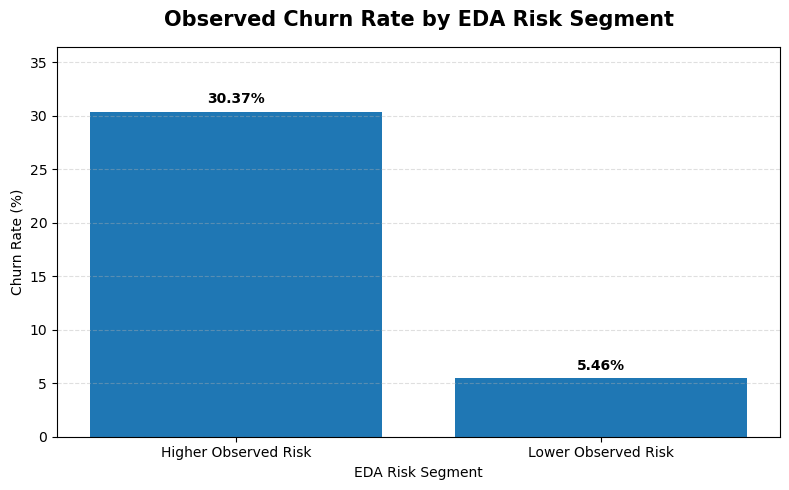

Chart saved to: d:\Customer_Segmentation_Churn_Banking\outputs\charts\39_eda_risk_segment_churn.png


In [143]:
eda_risk_plot = (
    eda_risk_summary
    .set_index("EDA_Risk_Segment")
    ["Churn_Rate"]
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    eda_risk_plot.index,
    eda_risk_plot.values
)

ax.set_title(
    "Observed Churn Rate by EDA Risk Segment",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("EDA Risk Segment")
ax.set_ylabel("Churn Rate (%)")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

for bar, value in zip(
    bars,
    eda_risk_plot.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_ylim(
    0,
    eda_risk_plot.max() * 1.20
)

plt.tight_layout()

chart_path = (
    chart_directory /
    "39_eda_risk_segment_churn.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {chart_path}")

In [144]:
final_eda_kpis = pd.DataFrame({
    "KPI": [
        "Overall Churn Rate",
        "Highest-Risk Country",
        "Highest Country Churn Rate",
        "Highest-Risk Age Group",
        "Highest Age-Group Churn Rate",
        "Female Churn Rate",
        "Male Churn Rate",
        "Inactive Customer Churn Rate",
        "Active Customer Churn Rate",
        "Engagement Drop Indicator",
        "High-Value Customer Churn Ratio",
        "High-Value Balance at Risk",
        "Two-Product Customer Churn Rate",
        "Low-Engagement Churn Rate",
        "Highly-Engaged Churn Rate"
    ],
    "Value": [
        round(overall_churn_rate, 2),
        "Germany",
        32.44,
        "51-60",
        56.21,
        25.07,
        16.46,
        round(inactive_churn_rate, 2),
        round(active_churn_rate, 2),
        round(
            engagement_drop_indicator,
            2
        ),
        round(high_value_churn_ratio, 2),
        round(balance_at_risk, 2),
        7.58,
        36.65,
        9.66
    ]
})

final_eda_kpis

,KPI,Value
0,Overall Churn Rate,20.37
1,Highest-Risk Country,Germany
2,Highest Country Churn Rate,32.44
3,Highest-Risk Age Group,51-60
4,Highest Age-Group Churn Rate,56.21
5,Female Churn Rate,25.07
6,Male Churn Rate,16.46
7,Inactive Customer Churn Rate,26.85
8,Active Customer Churn Rate,14.27
9,Engagement Drop Indicator,12.58


In [145]:
final_eda_kpis.to_csv(
    table_directory /
    "final_eda_kpi_summary.csv",
    index=False
)

print("Final EDA KPI summary saved.")

Final EDA KPI summary saved.


In [146]:
enriched_analytics_path = (
    data_directory /
    "bank_customer_churn_enriched.csv"
)

df.to_csv(
    enriched_analytics_path,
    index=False
)

print(
    f"Enriched analytics dataset saved to: "
    f"{enriched_analytics_path}"
)

print(
    f"Enriched dataset shape: {df.shape}"
)

Enriched analytics dataset saved to: d:\Customer_Segmentation_Churn_Banking\data\bank_customer_churn_enriched.csv
Enriched dataset shape: (10000, 23)


## Final Exploratory Data Analysis Findings

- The bank has an overall customer churn rate of **20.37%**.
- Age demonstrates a strong non-linear relationship with churn. Customers aged **51–60** record the highest churn rate at **56.21%**.
- Germany is the highest-risk region, with a churn rate of **32.44%**, approximately twice the rates observed in France and Spain.
- Female customers churn at **25.07%**, compared with **16.46%** among male customers.
- Customer tenure has a comparatively weak relationship with churn, with tenure-group churn rates remaining between **18.87% and 21.30%**.
- Customers with positive balances churn at **24.08%**, compared with **13.82%** among zero-balance customers.
- High-value customers record a churn ratio of **22.99%**, with approximately **58.71 million** in account balances associated with churned high-value customers.
- Product ownership has a strongly non-linear relationship with churn. Customers holding exactly **two products** record the lowest churn rate at **7.58%**.
- Inactive customers churn at **26.85%**, compared with **14.27%** among active customers.
- Low-engagement customers record a churn rate of **36.65%**, while highly engaged customers record only **9.66%**.
- Credit-card ownership and credit-score bands show comparatively weak differences in churn.
- The strongest observed churn patterns relate to age, geography, gender, activity status, engagement level, product count, and account balance.
- These findings justify the use of both raw features and engineered customer segments in the next stages of the project.

## Multivariate Analysis Findings

- Age has the strongest numerical correlation with churn at **0.28**, followed by active membership at **-0.16** and account balance at **0.12**.
- Customer activity has a negative relationship with churn, confirming that active customers are more likely to remain with the bank.
- Product count has only a weak linear correlation with churn, but segmented analysis shows a strong non-linear relationship.
- The highest-risk combined demographic segment is customers aged **51–60 in Germany**, with a churn rate of **69.55%**.
- Germany records higher churn than France and Spain across nearly every age group.
- Female customers have higher churn than male customers in all three countries.
- Female customers in Germany form the highest-risk gender-geography segment, with a churn rate of **37.55%**.
- Customers who are active and hold exactly two products record the lowest observed churn rate at **5.56%**.
- Customers with one product and inactive status record a churn rate of **36.65%**.
- The rule-based Higher Observed Risk segment records a churn rate of **30.37%**, compared with only **5.46%** in the Lower Observed Risk segment.
- The Higher Observed Risk segment captures approximately **89.25% of all churned customers**, demonstrating that age, geography, engagement, and product ownership together provide strong customer-risk differentiation.
- These multivariate findings justify carrying interaction features and customer segments into the feature-engineering and machine-learning stages.

In [147]:
# Check whether the enriched dataset exists
print("File exists:", enriched_analytics_path.exists())

# Reload the saved enriched dataset
df_enriched_check = pd.read_csv(enriched_analytics_path)

print("Enriched dataset loaded successfully.")
print("Dataset shape:", df_enriched_check.shape)

print("\nColumn names:")
for number, column in enumerate(
    df_enriched_check.columns,
    start=1
):
    print(f"{number:02d}. {column}")

File exists: True
Enriched dataset loaded successfully.
Dataset shape: (10000, 23)

Column names:
01. CustomerId
02. CreditScore
03. Geography
04. Gender
05. Age
06. Tenure
07. Balance
08. NumOfProducts
09. HasCrCard
10. Credit_Card_Status
11. IsActiveMember
12. Activity_Status
13. EstimatedSalary
14. Exited
15. Churn_Status
16. CreditScoreBand
17. AgeGroup
18. TenureGroup
19. BalanceStatus
20. BalanceSegment
21. HighValueCustomer
22. EngagementSegment
23. EDA_Risk_Segment


In [148]:
df_enriched_check.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,Credit_Card_Status,IsActiveMember,Activity_Status,EstimatedSalary,Exited,Churn_Status,CreditScoreBand,AgeGroup,TenureGroup,BalanceStatus,BalanceSegment,HighValueCustomer,EngagementSegment,EDA_Risk_Segment
0,15634602,619,France,Female,42,2,0.00,1,1,Has Credit Card,1,Active,"101,348.88",1,Churned,Fair,41-50,New,Zero Balance,Zero Balance,Standard Value,Moderately Engaged,Higher Observed Risk
1,15647311,608,Spain,Female,41,1,"83,807.86",1,0,No Credit Card,1,Active,"112,542.58",0,Retained,Fair,41-50,New,Positive Balance,Low Balance,Standard Value,Moderately Engaged,Higher Observed Risk
2,15619304,502,France,Female,42,8,"159,660.80",3,1,Has Credit Card,0,Inactive,"113,931.57",1,Churned,Poor,41-50,Loyal,Positive Balance,Premium Balance,High Value,Moderately Engaged,Higher Observed Risk
3,15701354,699,France,Female,39,1,0.00,2,0,No Credit Card,0,Inactive,"93,826.63",0,Retained,Good,31-40,New,Zero Balance,Zero Balance,Standard Value,Moderately Engaged,Lower Observed Risk
4,15737888,850,Spain,Female,43,2,"125,510.82",1,1,Has Credit Card,1,Active,"79,084.10",0,Retained,Excellent,41-50,New,Positive Balance,High Balance,Standard Value,Moderately Engaged,Higher Observed Risk


In [149]:
df_enriched_check.tail()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,Credit_Card_Status,IsActiveMember,Activity_Status,EstimatedSalary,Exited,Churn_Status,CreditScoreBand,AgeGroup,TenureGroup,BalanceStatus,BalanceSegment,HighValueCustomer,EngagementSegment,EDA_Risk_Segment
9995,15606229,771,France,Male,39,5,0.00,2,1,Has Credit Card,0,Inactive,"96,270.64",0,Retained,Excellent,31-40,Regular,Zero Balance,Zero Balance,Standard Value,Moderately Engaged,Lower Observed Risk
9996,15569892,516,France,Male,35,10,"57,369.61",1,1,Has Credit Card,1,Active,"101,699.77",0,Retained,Poor,31-40,Long-Term,Positive Balance,Low Balance,Standard Value,Moderately Engaged,Lower Observed Risk
9997,15584532,709,France,Female,36,7,0.00,1,0,No Credit Card,1,Active,"42,085.58",1,Churned,Good,31-40,Loyal,Zero Balance,Zero Balance,Standard Value,Moderately Engaged,Lower Observed Risk
9998,15682355,772,Germany,Male,42,3,"75,075.31",2,1,Has Credit Card,0,Inactive,"92,888.52",1,Churned,Excellent,41-50,Regular,Positive Balance,Low Balance,Standard Value,Moderately Engaged,Higher Observed Risk
9999,15628319,792,France,Female,28,4,"130,142.79",1,1,Has Credit Card,0,Inactive,"38,190.78",0,Retained,Excellent,18-30,Regular,Positive Balance,High Balance,Standard Value,Low Engagement,Higher Observed Risk


In [150]:
segmentation_columns = [
    "CreditScoreBand",
    "AgeGroup",
    "TenureGroup",
    "BalanceStatus",
    "BalanceSegment",
    "HighValueCustomer",
    "EngagementSegment",
    "EDA_Risk_Segment"
]

df_enriched_check[
    segmentation_columns
].head(10)

,CreditScoreBand,AgeGroup,TenureGroup,BalanceStatus,BalanceSegment,HighValueCustomer,EngagementSegment,EDA_Risk_Segment
0,Fair,41-50,New,Zero Balance,Zero Balance,Standard Value,Moderately Engaged,Higher Observed Risk
1,Fair,41-50,New,Positive Balance,Low Balance,Standard Value,Moderately Engaged,Higher Observed Risk
2,Poor,41-50,Loyal,Positive Balance,Premium Balance,High Value,Moderately Engaged,Higher Observed Risk
3,Good,31-40,New,Zero Balance,Zero Balance,Standard Value,Moderately Engaged,Lower Observed Risk
4,Excellent,41-50,New,Positive Balance,High Balance,Standard Value,Moderately Engaged,Higher Observed Risk
5,Fair,41-50,Loyal,Positive Balance,Medium Balance,Standard Value,Moderately Engaged,Higher Observed Risk
6,Excellent,41-50,Loyal,Zero Balance,Zero Balance,Standard Value,Highly Engaged,Higher Observed Risk
7,Poor,18-30,Regular,Positive Balance,Medium Balance,Standard Value,Moderately Engaged,Higher Observed Risk
8,Poor,41-50,Regular,Positive Balance,Premium Balance,High Value,Highly Engaged,Higher Observed Risk
9,Good,18-30,New,Positive Balance,High Balance,Standard Value,Moderately Engaged,Lower Observed Risk


In [151]:
print(
    "Total missing values:",
    df_enriched_check.isna().sum().sum()
)

df_enriched_check[
    segmentation_columns
].isna().sum()

Total missing values: 0


CreditScoreBand      0
AgeGroup             0
TenureGroup          0
BalanceStatus        0
BalanceSegment       0
HighValueCustomer    0
EngagementSegment    0
EDA_Risk_Segment     0
dtype: int64

In [152]:
for column in segmentation_columns:
    print(f"\n{column}:")
    print(
        df_enriched_check[column]
        .value_counts(dropna=False)
    )


CreditScoreBand:
CreditScoreBand
Fair         3350
Good         2397
Poor         2393
Excellent    1860
Name: count, dtype: int64

AgeGroup:
AgeGroup
31-40    4451
41-50    2320
18-30    1968
51-60     797
60+       464
Name: count, dtype: int64

TenureGroup:
TenureGroup
Loyal        3020
Regular      3010
New          2496
Long-Term    1474
Name: count, dtype: int64

BalanceStatus:
BalanceStatus
Positive Balance    6383
Zero Balance        3617
Name: count, dtype: int64

BalanceSegment:
BalanceSegment
Zero Balance       3617
Low Balance        1596
Premium Balance    1596
Medium Balance     1596
High Balance       1595
Name: count, dtype: int64

HighValueCustomer:
HighValueCustomer
Standard Value    8404
High Value        1596
Name: count, dtype: int64

EngagementSegment:
EngagementSegment
Moderately Engaged    4891
Highly Engaged        2588
Low Engagement        2521
Name: count, dtype: int64

EDA_Risk_Segment:
EDA_Risk_Segment
Higher Observed Risk    5987
Lower Observed Risk     

In [153]:
print("=" * 65)
print("ENRICHED DATASET VERIFICATION")
print("=" * 65)

print(f"File path       : {enriched_analytics_path}")
print(f"File exists     : {enriched_analytics_path.exists()}")
print(f"Dataset shape   : {df_enriched_check.shape}")
print(
    f"Missing values : "
    f"{df_enriched_check.isna().sum().sum():,}"
)
print(
    f"Duplicate IDs  : "
    f"{df_enriched_check['CustomerId'].duplicated().sum():,}"
)
print(
    f"Overall churn  : "
    f"{df_enriched_check['Exited'].mean() * 100:.2f}%"
)

print("\nRequired enriched columns:")

for column in segmentation_columns:
    status = (
        "Available"
        if column in df_enriched_check.columns
        else "Missing"
    )

    print(f"{column:<22}: {status}")

ENRICHED DATASET VERIFICATION
File path       : d:\Customer_Segmentation_Churn_Banking\data\bank_customer_churn_enriched.csv
File exists     : True
Dataset shape   : (10000, 23)
Missing values : 0
Duplicate IDs  : 0
Overall churn  : 20.37%

Required enriched columns:
CreditScoreBand       : Available
AgeGroup              : Available
TenureGroup           : Available
BalanceStatus         : Available
BalanceSegment        : Available
HighValueCustomer     : Available
EngagementSegment     : Available
EDA_Risk_Segment      : Available
